# 实现一个Transformer模型

In [1]:
import torch
import torch.nn as nn

## 实现一个Transformer模型需要什么？
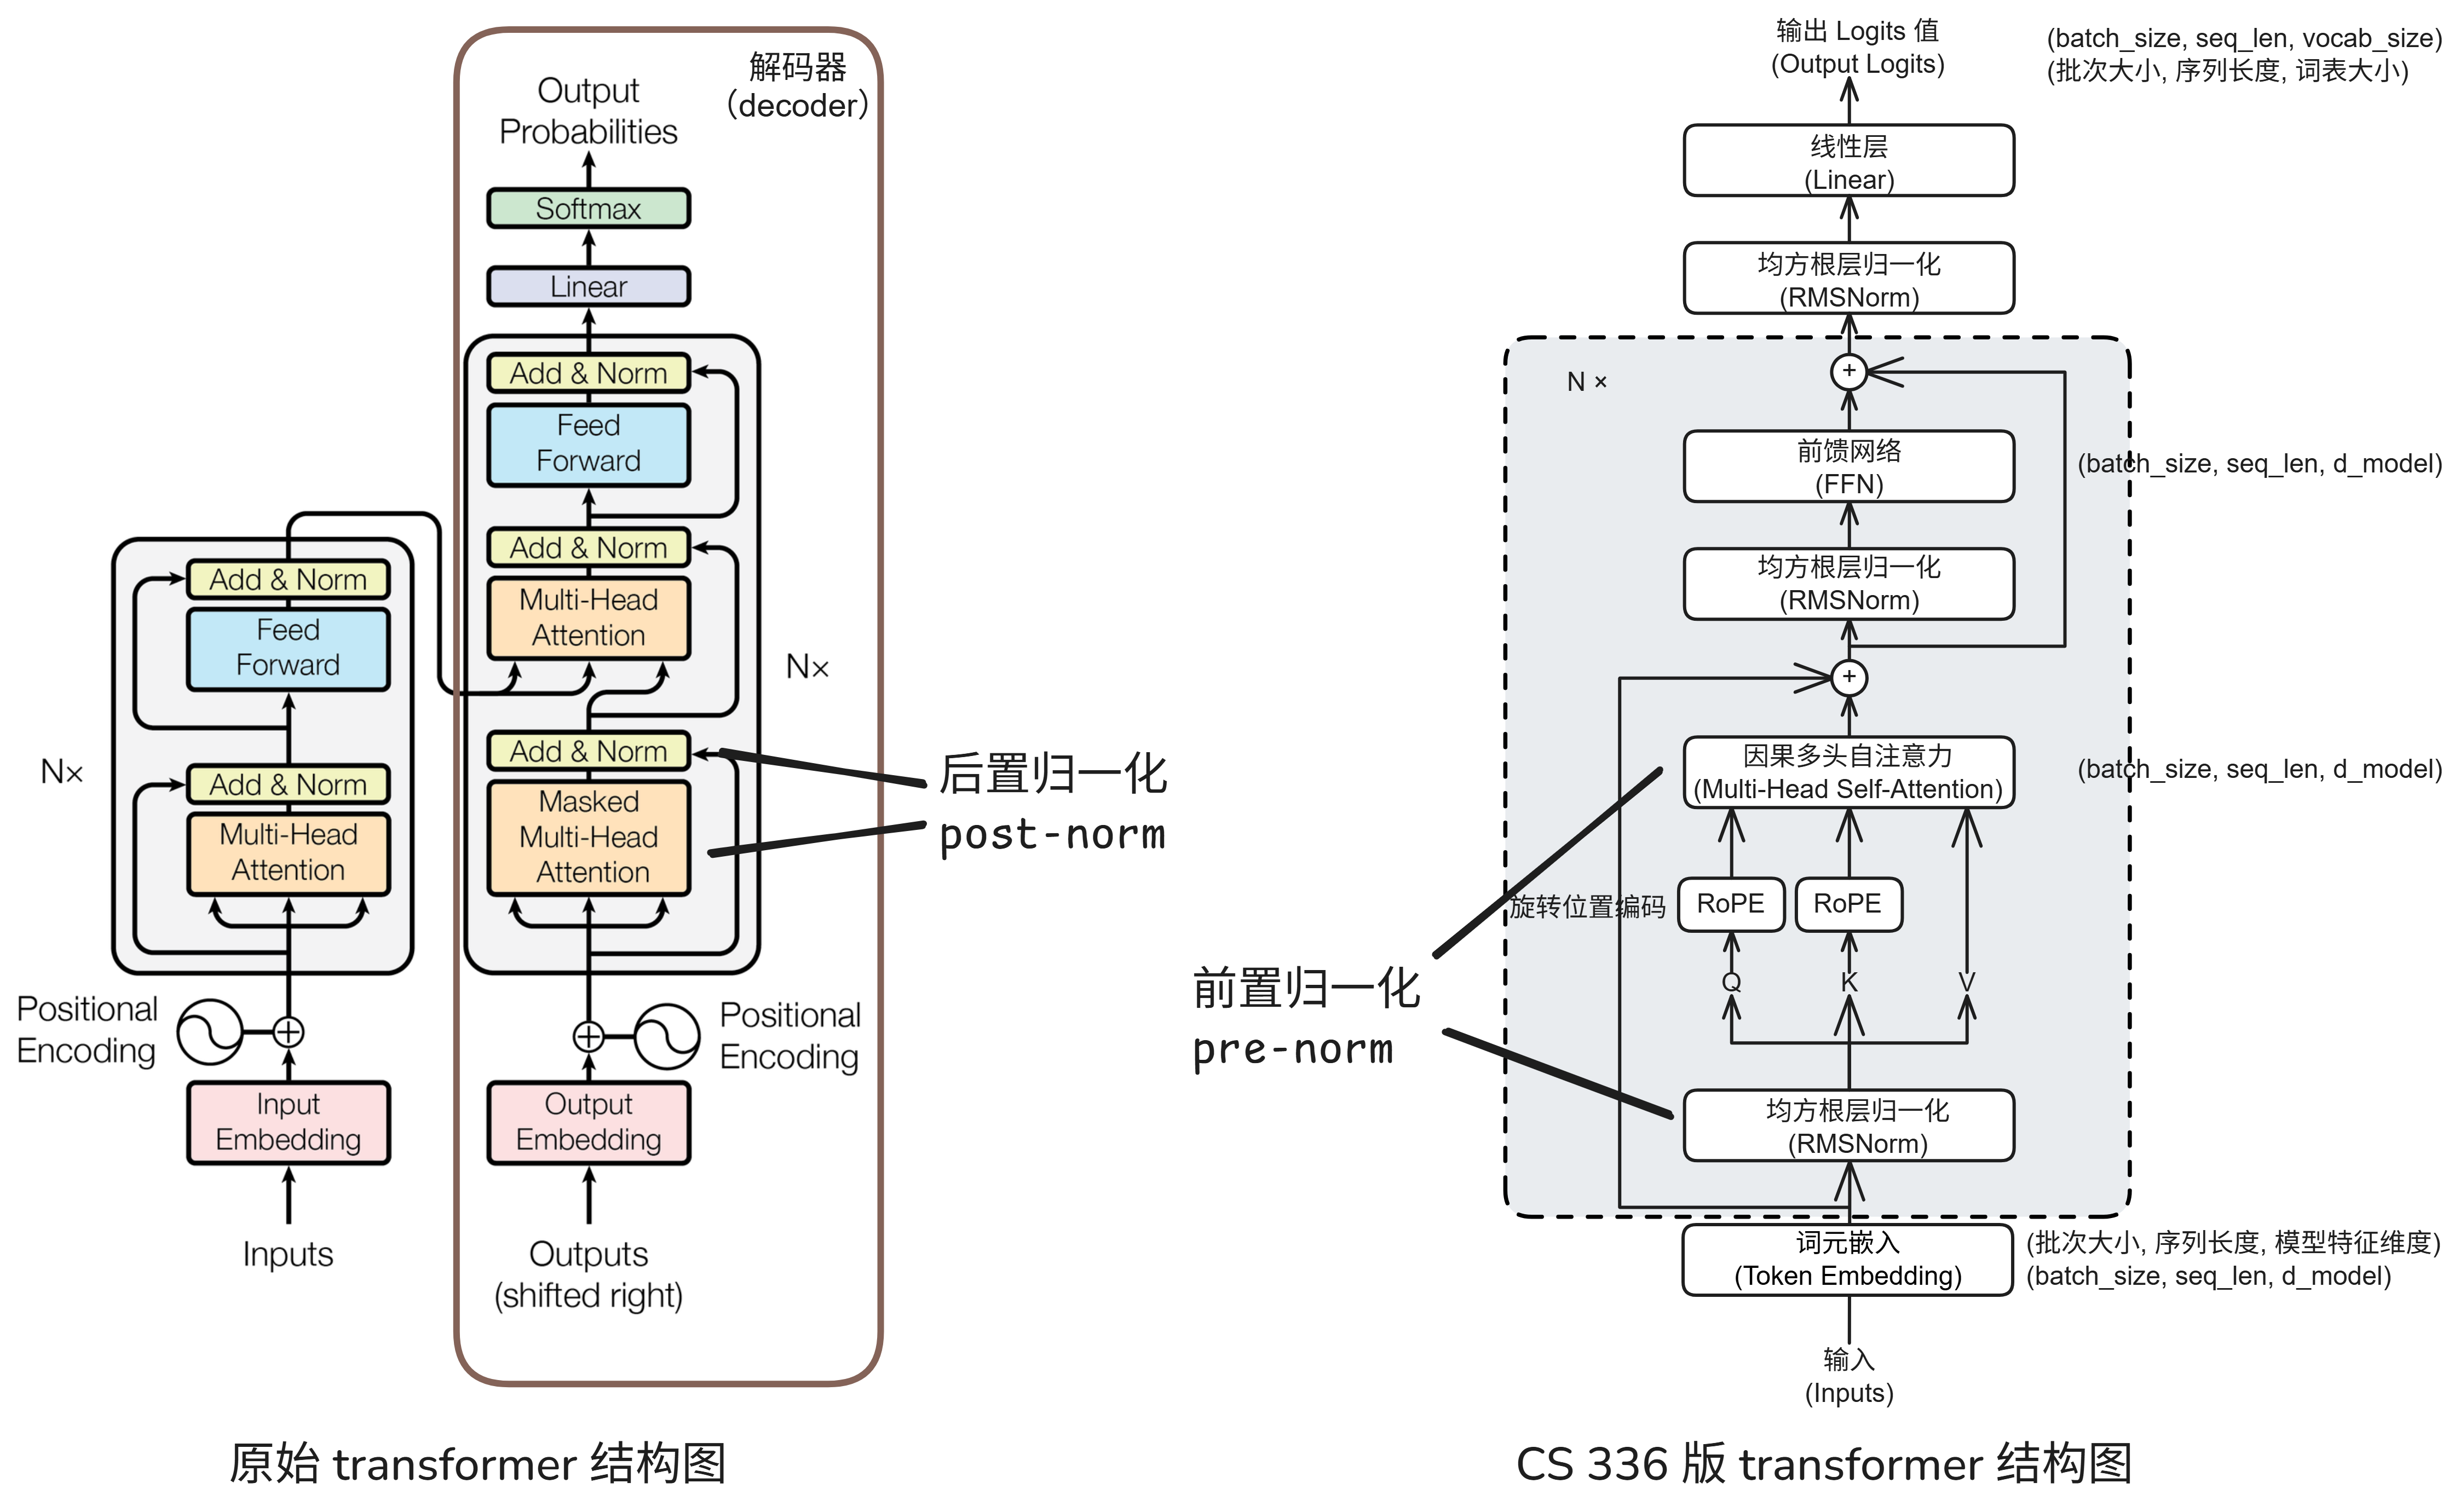


Input -> embedding -> RMSNorm -> RoPE -> MHA -> RMSNorm -> FFN -> RMSNorm -> Linear -> output_logits

先实现embedding
embedding: 输入x的维度是`[batch_size, seq_len]`, embedding之后把每个token都成一个向量，所以变化可以视为`[batch_size, seq_len, 1] -> [batch_size, seq_len, d_model]`
1 -> d_model的过程就是embedding，怎么实现？

在词表里按id查词，把对应的词转换成对应的向量

需要词表大小，以及向量长度，即模型特征维度

In [2]:
class Embedding(nn.Module):
    def __init__(self, nums_embeddings, d_model):
        super().__init__()
        self.embd = nn.Parameter(torch.empty(nums_embeddings, d_model))
        nn.init.trunc_normal_(self.embd, mean=0, std=1, a=-3, b=3) # 带截断的初始化
    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        return self.embd[token_ids] # pytorch 索引操作，等价于 torch.index_select
        # 用 token_ids 中的每个元素去索引 self.embed 的第 0 维，形状变化为：(batch_size, seq_len) -> (batch_size, seq_len, embed_dim); id = 0 -> self.embed[0]

后面会用到很多矩阵乘法，先写一个方便的线性层用于运行矩阵运算
当前的线性层一般都不加bias了，省计算
其实就是`nn.Linear()`的手动实现

In [3]:
class Linear(nn.Module):
    def __init__(self, in_features, out_features, mean=None, std=None, bias=None):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_features, out_features))
        mean = 0 if mean is None else mean
        std = 2 / (in_features+out_features) ** 0.5 if std is None else std
        nn.init.trunc_normal_(self.weight, mean=mean, std=std, a=-3 * std, b=3 * std)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.matmul(x, self.weight)

直接matmul不用转置也行，pytorch会自动转置，和`x @ self.weight.T`是一样的

然后实现RMSNorm，RMSNorm的具体内容如下：
给定激活向量 $\boldsymbol a \in \mathbb R^{d_\text{model}}$，RMSNorm 对每个激活分量 $a_i$ 的缩放计算如下：
$$\text{RMSNorm}(a_i) = \frac{a_i}{\text{RMS}(\boldsymbol a)} \, g_i$$
其中，$\text{RMS}(\boldsymbol a) = \sqrt{\frac{1}{d_\text{model}} \sum_{i=1}^{d_\text{model}} a_i^2 + \varepsilon}$。式中，$g_i$ 为可学习的增益参数（这样的参数总共有 d_model 个），$\varepsilon$ 为超参数，通常固定取 $10^{-5}$。

In [4]:
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-5):
        super().__init__()
        self.g = nn.Parameter(torch.ones(d_model)) # 初始化为全1
        self.eps = eps
        self.d_model = d_model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms = torch.sqrt(torch.sum(x**2, dim=-1, keepdim=True) / self.d_model + self.eps) # keepdim方便广播
        return (x / rms) * self.g

接下来做RoPE

对于位置 i 处的查询向量 $q^{(i)} = W_q x^{(i)} \in \mathbb{R}^d$，RoPE 通过旋转矩阵 $R^i \in \mathbb{R}^{d×d}$ 对其施加旋转变换，得到： $q'^{(i)} = R^i \, q^{(i)}$
旋转矩阵将查询向量里的元素两两分组进行旋转，第 k 组对应的旋转角度为$\theta_{i,k} = \dfrac{i}{\Theta^{(2k-2)/d}}$，$k \in \{1, 2, \dots, d/2\}$。其中 $\Theta$ 为常数基底。对应的二维旋转子矩阵为：
$$R_{i,k} = \begin{pmatrix}
\cos(\theta_{i,k}) & -\sin(\theta_{i,k}) \\
\sin(\theta_{i,k}) & \cos(\theta_{i,k})
\end{pmatrix} \tag{5}$$
完整的旋转矩阵 $R^i$ 为分块对角矩阵，矩阵中的 0 均代表 2×2 零矩阵：
$$R_i = \begin{pmatrix}
R_{i,1} & 0 & 0 & \cdots & 0 \\
0 & R_{i,2} & 0 & \cdots & 0 \\
0 & 0 & R_{i,3} & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & R_{i,d/2}
\end{pmatrix} \tag{6}$$

需要什么？

数学公式常把 $q$ 当列向量，所以写 $Rq$；PyTorch 里 token 的特征通常横着放在最后一维，可以视为行向量，所以对应 $qR^T$。



In [5]:
class RoPE(nn.Module):
    def __init__(self, theta, d_k, max_seq_len):
        super().__init__()
        '''
        theta: float  RoPE 的 Θ 值
        d_k: int  待编码的向量维度（一般指多头注意力层里 query 和 key 向量的维度）
        max_seq_len: int  输入的最大序列长度
        '''
        assert d_k % 2 == 0
        positions = torch.arange(max_seq_len)
        k_indices = torch.arange(0, d_k / 2)

        freq = theta ** -(k_indices / (d_k / 2))
        # 预计算频率与角度表
        # 旋转角度 angle[i][k] = i/(theta**((k-1)/(d/2))), i 为 token 位置下标，k 为词向量内的元素两两分组的组号
        angles = positions[:, None] * freq[None, :]
        cos_table = torch.cos(angles)
        sin_table = torch.sin(angles)
        # 把预先计算好的 cos 表和 sin 表注册为 buffer 缓存起来，方便以后重复使用
        self.register_buffer('cos_table', cos_table)
        self.register_buffer('sin_table', sin_table)
    def forward(self, x: torch.Tensor, token_position: torch.Tensor) -> torch.Tensor:
        '''
        x: (..., seq_len, d_k) 输入张量
        token_positions: (..., seq_len) 存储每个 token 的位置下标，支持位置非连续的 token 序列： (1, 3, 5, 7...)
        return: (..., seq_len, d_k) 旋转位置编码后的张量
        '''
        # 两两分组后执行旋转
        # 把最后一维 d_k 按「每 2 个元素为一组」切开，每组 [x_even, x_odd]，全部组的偶数元素汇总为 x1，奇数元素汇总为 x2
        x1 = x[..., 0::2]
        x2 = x[..., 1::2]
        cos = self.cos_table[token_position] # (..., seq_len) -> (..., seq_len, d_k//2): 使用 token 位置下标 i 对 cos 表的第 0 维取元素，取得第 i 行的 cos 序列
        sin = self.sin_table[token_position] # (..., seq_len) -> (..., seq_len, d_k//2): 使用 token 位置下标 i 对 sin 表的第 0 维取元素，取得第 i 行的 sin 序列
        # 分别对奇数位置的元素和偶数位置的元素执行不同的旋转操作
        x1_rot = x1 * cos - x2 * sin
        x2_rot = x1 * sin + x2 * cos
        # 拼接回原始形状
         # x_rot = torch.concat([x1_rot, x2_rot], dim=-1) # 用 concat 导致最后一维元素的顺序会变为 (x0, x2, x1, x3)，不符合原始的 (x0, x1, x2, x3)
        x_rot = torch.stack([x1_rot, x2_rot], dim=-1)
        x_rot = x_rot.flatten(-2)
        return x_rot

RoPE 的核心思想非常简单：

> 将 Query / Key 向量的维度两两分组，每两个元素看成一个二维向量，然后根据 token 的位置，对每个二维向量执行旋转。

对于一个 $d_k$ 维向量：
$$
x=(x_0,x_1,x_2,x_3,\dots,x_{d_k-2},x_{d_k-1})
$$
将其两两分组：
$$
(x_0,x_1),\quad
(x_2,x_3),\quad
\dots,\quad
(x_{d_k-2},x_{d_k-1})
$$
因此要求：
$$
d_k \bmod 2 = 0
$$
### 1. 为不同维度组定义旋转频率
代码：
```
k_indices = torch.arange(d_k // 2)
freq = theta ** -(k_indices / (d_k / 2))
````
因为一共有 $d_k/2$ 个二维组，所以：

$$
k=0,1,\dots,\frac{d_k}{2}-1
$$
第 $k$ 组的频率定义为：
$$
\omega_k
=
\Theta^{-\frac{k}{d_k/2}}
$$
由于：
$$
\frac{k}{d_k/2}
=
\frac{2k}{d_k}
$$
所以也可以写成：
$$
\boxed{
\omega_k
=
\Theta^{-\frac{2k}{d_k}}
}
$$
也就是原始 RoPE 中常见的形式。
这里的 $\Theta$ 一般是一个较大的常数，例如：
$$
\Theta=10000
$$
不同的二维组具有不同频率，因此不同维度会以不同速度旋转。
### 2. token 位置决定旋转角度

代码：
```
positions = torch.arange(max_seq_len)
angles = positions[:, None] * freq[None, :]
```
假设某个 token 的位置为 $i$，那么第 $k$ 个二维组的旋转角度为：
$$
\phi_{i,k}
=
i\omega_k
$$
代入 $\omega_k$：
$$
\boxed{
\phi_{i,k}
=
\frac{i}{\Theta^{2k/d_k}}
}
$$
因此：
* token 位置 $i$ 越大，旋转角度越大；
* 不同维度组 $k$ 的旋转速度不同。

代码利用广播：
```
positions[:, None] : (max_seq_len, 1)
freq[None, :]      : (1, d_k/2)
```
得到：
```
angles : (max_seq_len, d_k/2)
```
其中：
$$
\text{angles}[i,k]=\phi_{i,k}
$$
### 3. 预计算 sin 和 cos
代码：
```
cos_table = torch.cos(angles)
sin_table = torch.sin(angles)
self.register_buffer("cos_table", cos_table)
self.register_buffer("sin_table", sin_table)
```
因此提前保存：
$$
\cos\phi_{i,k}
$$
和：
$$
\sin\phi_{i,k}
$$
之后 forward 时不需要重新计算三角函数。
`register_buffer` 的作用是：
* 它不是需要训练的参数；
* 但会随着模型一起移动到 CPU / GPU；
* 也会被保存在 `state_dict` 中。

Forward：真正执行 RoPE
假设输入：
```
x.shape = (..., seq_len, d_k)
```
最后一个维度就是每个 Query / Key 向量的维度。
### 4. 将向量两两分组
```
x1 = x[..., 0::2]
x2 = x[..., 1::2]
```
假设：
$$
x=(x_0,x_1,x_2,x_3,x_4,x_5)
$$
```
x[..., 0::2]
```
得到：
$$
(x_0,x_2,x_4)
$$
而：
```
x[..., 1::2]
```
得到：
$$
(x_1,x_3,x_5)
$$
$$
(x_0,x_1),
\quad
(x_2,x_3),
\quad
(x_4,x_5)
$$
### 5. 根据 token 位置查询旋转角度
```
cos = self.cos_table[token_position]
sin = self.sin_table[token_position]
```

```
token_position = [0, 1, 2, 3]
```
$$
\cos\phi_{0,k},
\quad
\cos\phi_{1,k},
\quad
\cos\phi_{2,k},
\quad
\cos\phi_{3,k}
$$

$$
\sin\phi_{i,k}
$$
因此，每个 token 都会获得与自己位置对应的旋转角度。
### 6. 执行二维旋转

```
x1_rot = x1 * cos - x2 * sin
x2_rot = x1 * sin + x2 * cos
```

考虑第 $k$ 个二维组：
$$
(x_{2k},x_{2k+1})
$$

旋转之后：
$$
x'_{2k}
=
x_{2k}\cos\phi-x_{2k+1}\sin\phi
$$

$$
x'_{2k+1}=x_{2k}\sin\phi+x_{2k+1}\cos\phi
$$
$$
\boxed{
\begin{pmatrix}
x'_{2k}\\
x'_{2k+1}
\end{pmatrix}
=
\begin{pmatrix}
\cos\phi & -\sin\phi\\
\sin\phi & \cos\phi
\end{pmatrix}
\begin{pmatrix}
x_{2k}\\
x_{2k+1}
\end{pmatrix}
}
$$

因此，RoPE 本质上没有复杂操作：

> 对 Query / Key 向量中的每两个元素执行一次二维旋转。

### 7. 为什么代码中没有显式的旋转矩阵？

数学上我们可以写：

$$
x'=Rx
$$

其中：

$$
R=
\begin{pmatrix}
\cos\phi & -\sin\phi\\
\sin\phi & \cos\phi
\end{pmatrix}
$$

但代码没有真的创建这个 $2\times2$ 矩阵。

而是直接展开矩阵乘法：

$$
x'_1=x_1\cos\phi-x_2\sin\phi
$$

$$
x'_2=x_1\sin\phi+x_2\cos\phi
$$

```
x1_rot = x1 * cos - x2 * sin
x2_rot = x1 * sin + x2 * cos
```
---

### 8. 行向量和列向量的区别
数学教材通常把向量写成列向量：
$$
q=
\begin{pmatrix}
x_1\\
x_2
\end{pmatrix}
$$
因此写作：
$$
q'=Rq
$$
其中：
$$
R=
\begin{pmatrix}
\cos\phi&-\sin\phi\\
\sin\phi&\cos\phi
\end{pmatrix}
$$
但在 PyTorch 中，一个 token 通常存放在最后一个维度：

```
(..., seq_len, d_k)
```

因此一个 token 更自然地可以看成行向量：

$$
q=(x_1,x_2)
$$
同一个旋转就可以写成：
$$
q'=qR^T
$$

$$
(x'_1,x'_2)
=
(x_1,x_2)
\begin{pmatrix}
\cos\phi&\sin\phi\\
-\sin\phi&\cos\phi
\end{pmatrix}
$$

所以：

$$
\boxed{
Rq_{\text{column}}
\quad\Longleftrightarrow\quad
q_{\text{row}}R^T
}
$$
它们描述的是完全相同的旋转，只是行向量和列向量的表示方式不同。
代码本身实际上没有做显式的 $Rq$ 或 $qR^T$，而是直接计算旋转后的两个坐标。
### 9. 将旋转后的元素重新拼回去

```
x_rot = torch.stack([x1_rot, x2_rot], dim=-1)
```

$$
x1_{\text{rot}}
=
(x'_0,x'_2,x'_4)
$$

$$
x2_{\text{rot}}
=
(x'_1,x'_3,x'_5)
$$

`stack` 后得到：

$$
((x'_0,x'_1),
(x'_2,x'_3),
(x'_4,x'_5))
$$
shape 为：
```
(..., seq_len, d_k/2, 2)
```

然后：

```
x_rot = x_rot.flatten(-2)
```

将最后两个维度合并：
$$
((x'_0,x'_1),
(x'_2,x'_3),
(x'_4,x'_5))
$$

恢复为：

$$
\boxed{
(x'_0,x'_1,x'_2,x'_3,x'_4,x'_5)
}
$$

最终 shape 又回到：

```
(..., seq_len, d_k)
```


接下来是想办法实现MHA

实现MHA就要把一个大矩阵拆开成多个`d_model * d_model`大小的矩阵，所以需要，还需要RoPE（所以也就需要对应参数）

还有下三角矩阵的mask

还需要实现一个缩放点积注意力，在此之前还要实现softmax

现代的softmax还会每个位置减去本维度最大值

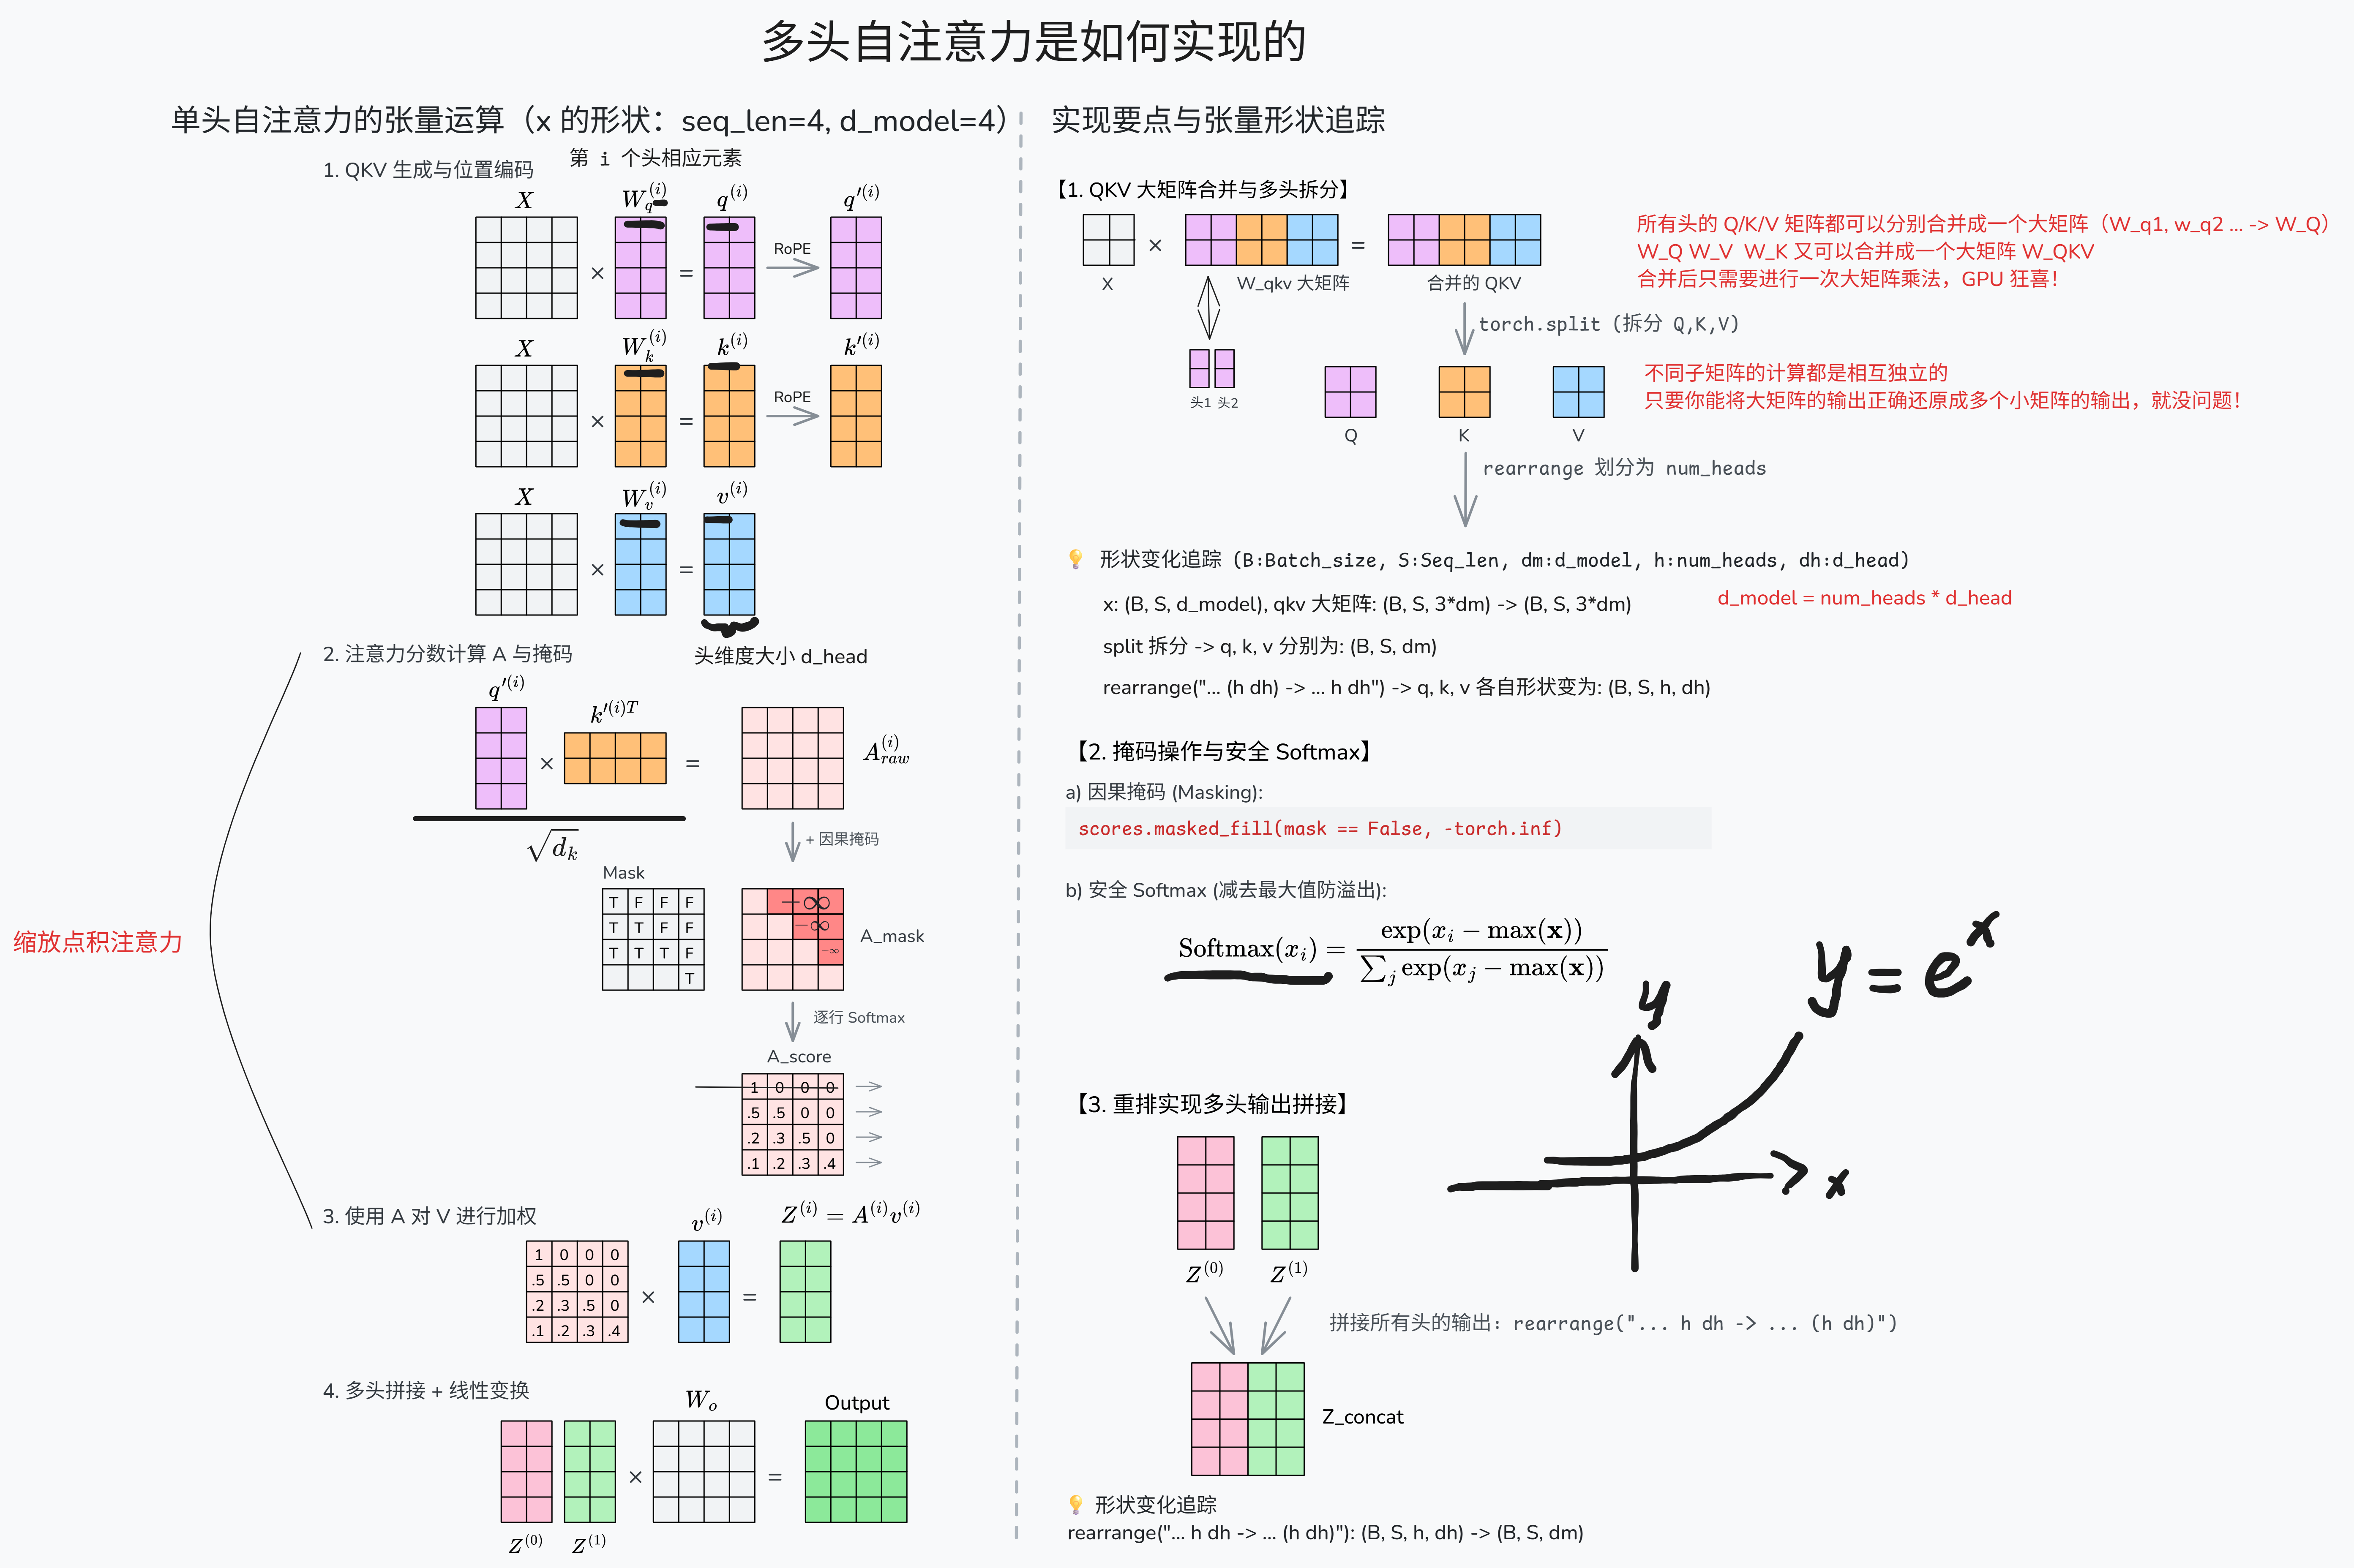

In [6]:
def softmax(x: torch.Tensor, i: int) -> torch.Tensor:
    # .max() 的返回值是一个元组: (最大值张量, 最大值下标张量)，元组里的元素不可修改，列表里的元素可以修改
    x -= torch.max(x, dim=i, keepdim=True)[0] # 假设 i = -1: x: (... dim) x.max: (... 1) -> (... dim) keepdim是为了能够用广播机制方便减法
    return torch.exp(x) / torch.exp(x).sum(dim=i, keepdim=True)

In [7]:
def attn(q, k, v, mask):
        score = q @ k.transpose(-2, -1) / (q.shape[-1] ** 0.5)
        score = torch.masked_fill(score, mask == False, -torch.inf)
        score = softmax(score, -1)
        y = score @ v
        return y


In [8]:
class MHA(nn.Module):
    def __init__(self, d_model: int, nums_head: int, rope_theta: float, max_seq_len: int):
        super().__init__()
        self.d_model = d_model
        self.d_head = d_model // nums_head # 计算每个头的向量维度
        self.nums_head = nums_head
        self.w_qkv = Linear(d_model, 3 * d_model) # 所有头的 qkv 矩阵合并成一个大矩阵: 输出维度 out_dim = num_heads * d_head * 3
        self.rope = RoPE(rope_theta, d_k=self.d_head, max_seq_len=max_seq_len) if rope_theta > 0 else None
        self.w_output = Linear(d_model, d_model)
    def forward(self, x: torch.Tensor, token_positions: torch.Tensor=None) -> torch.Tensor:
        '''
        :param x: 输入张量: (batch_size, seq_len, d_model)
        :param token_positions: 每个 token 的位置下标 (batch_size, seq_len)，为 None 自动生成 0~seq_len‑1
        :return: (batch_size, seq_len, d_model)
        '''
        qkv = self.w_qkv(x)
        q, k, v = torch.split(qkv, self.d_model, dim=-1)
        B, S, _ = q.shape
        # 拆分多头：把 d_model 拆成 num_heads × d_head，num_heads 放到 seq 前面，匹配 rope 的代码（回顾一下 rope 对输入 x 的要求）
        # (B, S, num_heads*d_head) → (B, num_heads, S, d_head)
        q = q.reshape(B, S, self.nums_head, self.d_head).transpose(1, 2)
        k = k.reshape(B, S, self.nums_head, self.d_head).transpose(1, 2)
        v = v.reshape(B, S, self.nums_head, self.d_head).transpose(1, 2)
        q = self.rope(q, token_positions)
        k = self.rope(k, token_positions)

        seq_len = x.shape[1]
        mask = torch.tril(torch.ones((seq_len, seq_len))).bool()
        output_head = attn(q, k, v, mask)
        # 多头结果拼接: (B, n_heads, S, d_head) → (B, S, n_heads*d_head=d_model)
        output_head = output_head.transpose(1, 2)
        output_head = output_head.reshape(B, S, self.d_model)
        output = self.w_output(output_head)
        return output

[B, S, 4096] (假设embedding后维度是4096)

-> W_QKV [B, S, 12288]

-> split 成 Q, K, V 3*[B, S, 4096](Q: [B, S, 4096]K: [B, S, 4096]V: [B, S, 4096])

-> 拆 32 个 head [B, S, 32, 128]

-> 把 head 移到 seq 前面[B, 32, S, 128]

-> RoPE(Q: [B, 32, S, 128] K: [B, 32, S, 128])

-> Q @ K^T [B, 32, S, 128]@[B, 32, 128, S]

-> attention score [B, 32, S, S]

-> softmax [B, 32, S, S]

-> score @ V [B, 32, S, S]@[B, 32, S, 128]

-> 每个 head 的输出 [B, 32, S, 128]

-> 把 head 移回来 [B, S, 32, 128]

-> 合并 32 个 head [B, S, 4096]

-> W_output [B, S, 4096]

### 为什么要变换 Q、K、V 的维度？
经过线性层后：
$$
Q,K,V \in \mathbb{R}^{B\times S\times d_{model}}
$$
多头注意力要求每个 head 独立计算，因此先把：
$$
d_{model}=n_{head}\times d_{head}
$$
拆开：
$$
(B,S,d_{model})
\rightarrow
(B,S,n_{head},d_{head})
$$
所以有`q.reshape(B, S, self.nums_head, self.d_head)`

然后把 `num_heads` 移到 `seq` 前面：
$$
(B,S,n_{head},d_{head})
\rightarrow
(B,n_{head},S,d_{head})
$$
这样在计算：
$$
QK^T
$$
时，`B` 和 `n_head` 都作为批次维度，真正参与矩阵乘法的是最后两维：
$$
(S,d_{head})\times(d_{head},S)
\rightarrow
(S,S)
$$
所以有`.transpose(1, 2)`

因此每个 head 都能独立得到自己的注意力矩阵。
> 本质上：先把隐藏在 `d_model` 里的多个 head 拆出来，再把 `head` 放到前面作为批次维度，方便每个 head 并行、独立地计算注意力。

In [9]:
class FFN(nn.Module):
    def __init__(self, d_model, d_ff: int = 512):
        super().__init__()
        self.d_ff = 64 * (8 * d_model // 3 // 64)
        self.w1, self.w3 = Linear(d_model, d_ff), Linear(d_model, d_ff)
        self.w2 = Linear(d_ff, d_model)
    def forward(self, x):
        y1 = self.w1(x)
        y1 = y1 * torch.sigmoid(y1)
        y3 = self.w3(x)
        y = self.w2(y1 * y3)
        return y


实现FFN

做一个SwiGLU
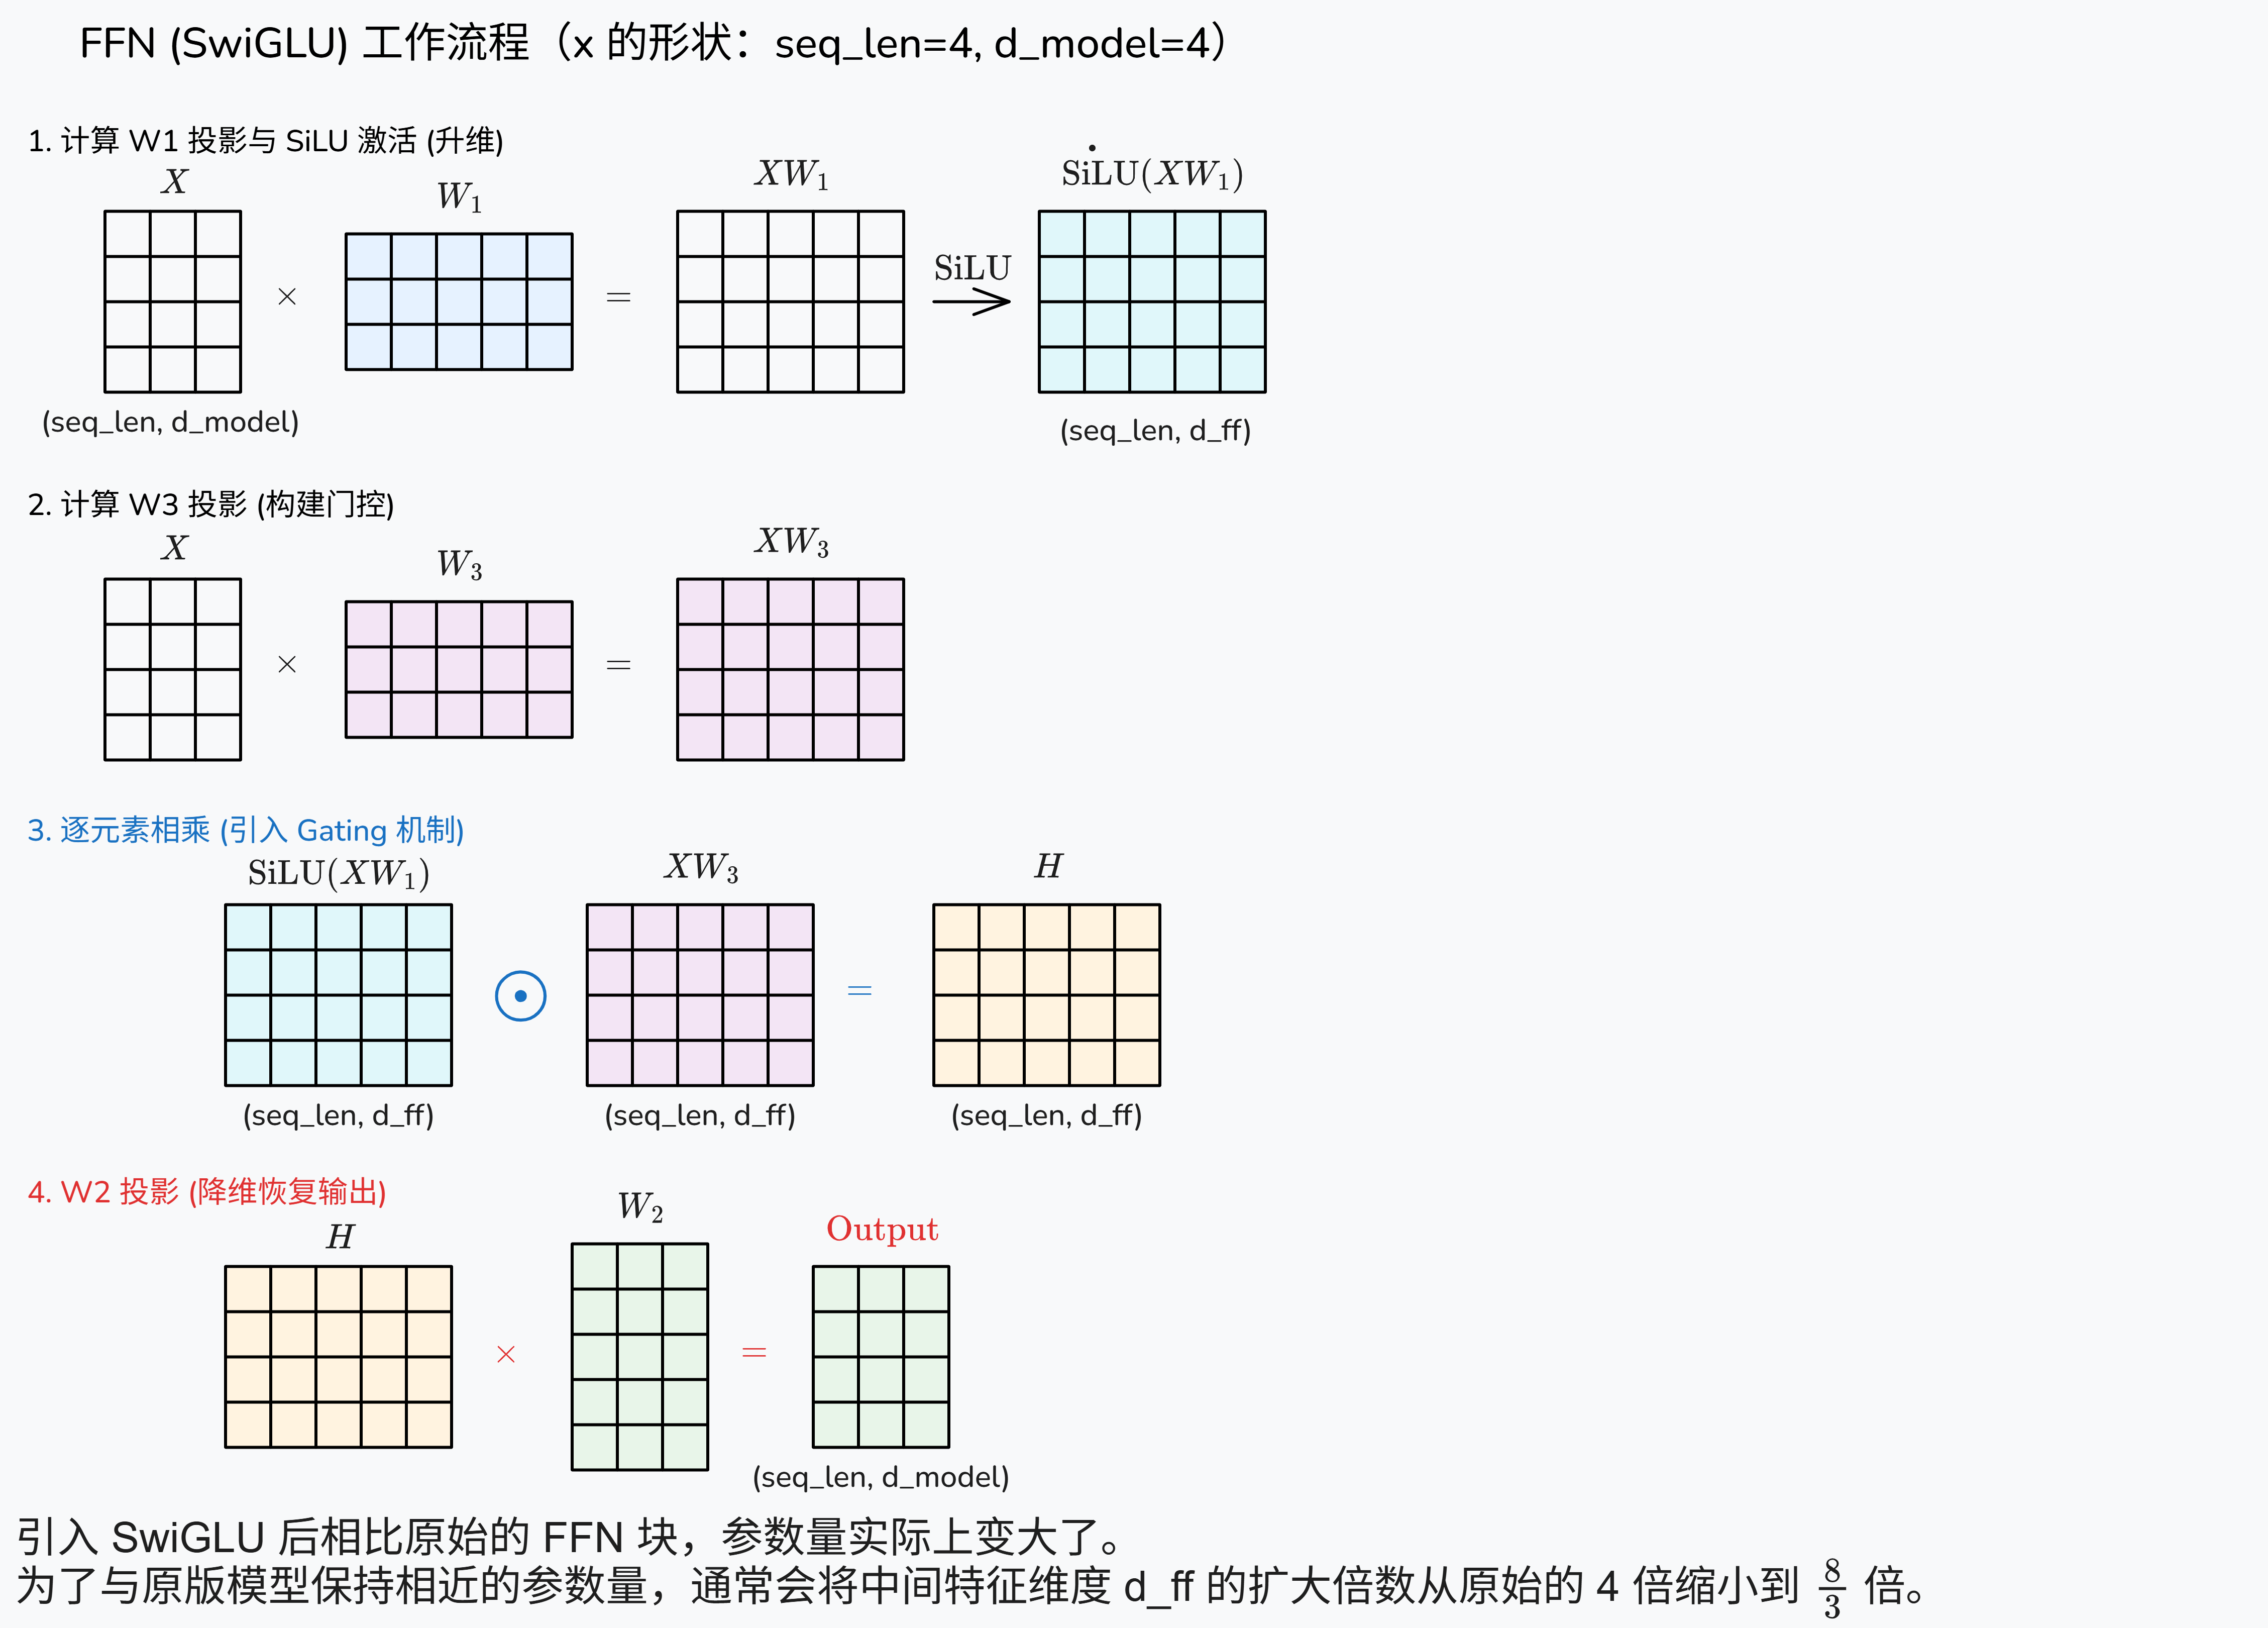

SwiGLU 完整的数学形式如下：
$$\text{FFN}(x) = W_2 \left( \text{SiLU}(W_1 x) \odot W_3 x \right)$$
其中 $W_1, W_3 \in \mathbb{R}^{d_{ff} \times d_{model}}$，$W_2 \in \mathbb{R}^{d_{model} \times d_{ff}}$，$\odot$ 表示逐元素相乘。SiLU（又称 Swish）激活函数 $\text{SiLU}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$，是 ReLU 的平滑版本。中间层维度 $d_{ff} = \frac{8}{3} d_{model}$

所有需要的组件已经准备好，实现transformer
实现transformer block，然后再拼起整个组件
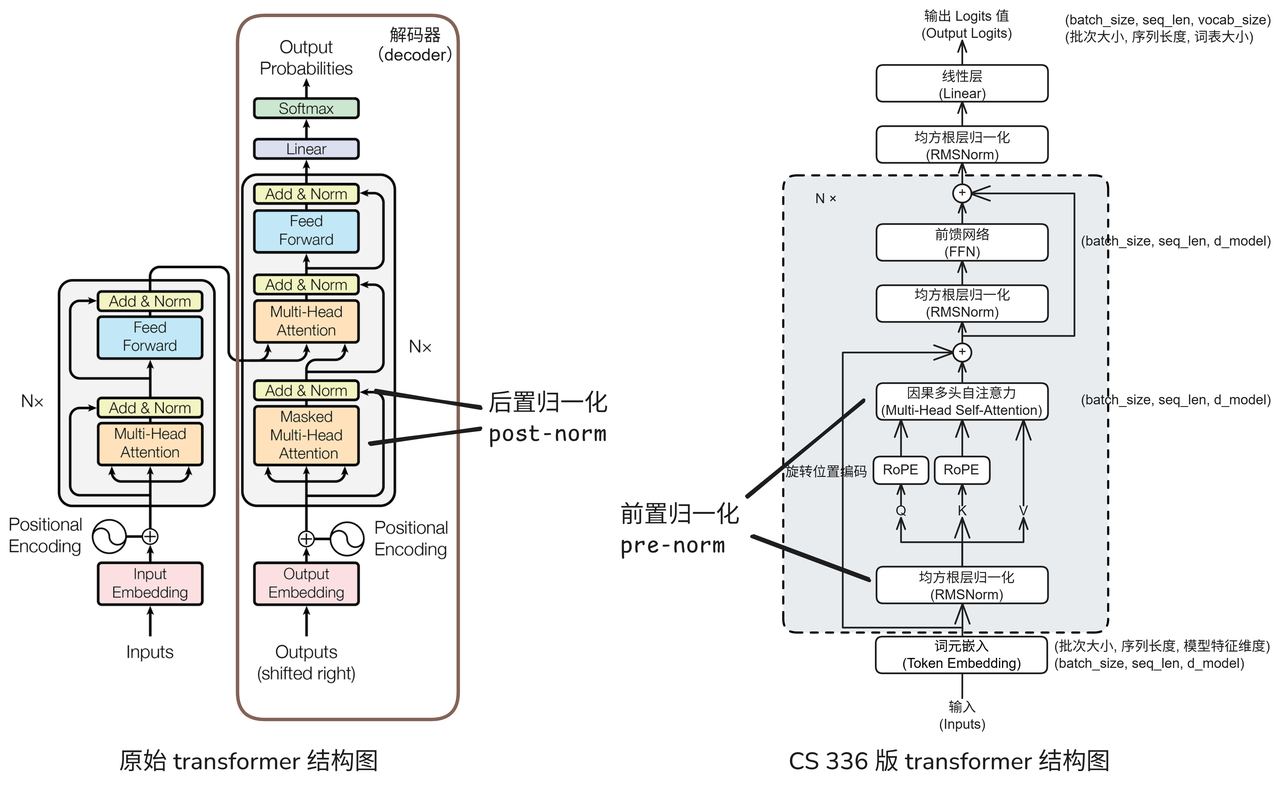

In [10]:
class TransformerBlock(nn.Module):
    def __init__(self,d_model: int, nums_head: int, rope_theta: float, max_seq_len: int):
        super().__init__()
        self.pre_norm1 = RMSNorm(d_model)
        self.mha = MHA(d_model, nums_head, rope_theta, max_seq_len)

        self.pre_norm2 = RMSNorm(d_model)
        self.ffn = FFN(d_model)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.mha(self.pre_norm1(x))
        y = x + self.ffn(self.pre_norm2(x))
        return y

In [11]:
class TransformerLM(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, num_heads: int, d_ff: int, rope_theta: float, context_length: int, num_layers: int):
        super().__init__()
        self.embd = Embedding(vocab_size, d_model)
        self.transformerBlocks = nn.Sequential(*[TransformerBlock(d_model, num_heads, rope_theta, context_length) for _ in range(num_layers)])
        self.finalNorm = RMSNorm(d_model)
        self.lmHead = Linear(d_model, vocab_size)
    def forward(self, x):
        y = self.embd(x)
        y = self.transformerBlocks(y)
        y = self.finalNorm(y)
        y = self.lmHead(y)
        return y

# 模型训练

先确定训练模型需要的组件：
1. Loss function, 使用交叉熵函数作为损失函数
2. Optimizer，实现AdamW
3. Training Lopp，所有支撑设施——加载数据，保存模型权重，管理整个训练过程（学习率调度，梯度裁剪，日志与验证）

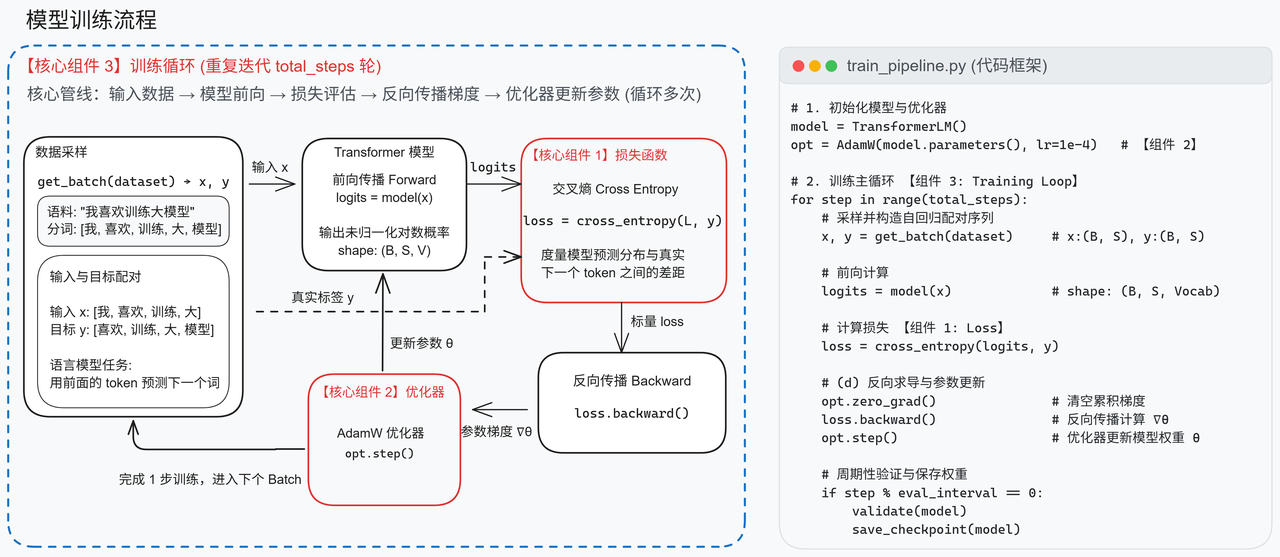

## 交叉熵损失
语言模型对序列中的每个位置 $i$预测下一个 token 的条件分布 $p_\theta(x_{i+1} \mid x_{1:i})$。训练目标是让下一个位置的真实 token 的概率尽可能大，即交叉熵尽可能小。标准交叉熵（负对数似然）函数定义如下：
$$\ell(\theta; D) = \frac{1}{|D|\,m} \sum_{x \in D} \sum_{i=1}^{m} -\log p_\theta(x_{i+1} \mid x_{1:i})$$
模型输出的是每个位置的 logits $o_i \in \mathbb{R}^{vocab\_size}$，位置 $i$处的 ${p(x_{i+1}\mid x_{1:i})}$为：
$$p(x_{i+1} \mid x_{1:i}) = \mathrm{softmax}(o_i)[x_{i+1}] = \frac{\exp(o_i[x_{i+1}])}{\sum_{a=1}^{vocab\_size} \exp(o_i[a])}$$
$o_i[k]$表示向量 $o_i$ 的 k 号元素，即词表中编号为 k 的 token 对应的 logit 分数。$o_i$ 应被理解为给定 $x_{1:i}$ 后模型输出的logits，需要用它来获得 $x_{i+1}$ 的输出
> 在因果掩码的帮助下，模型跑一次前向传播就能同时预测所有位置的 next-token 分布，批量计算出损失后，就可以一次在多个样本上进行反向传播与参数更新，这也是 transformer 类模型的一大优势。

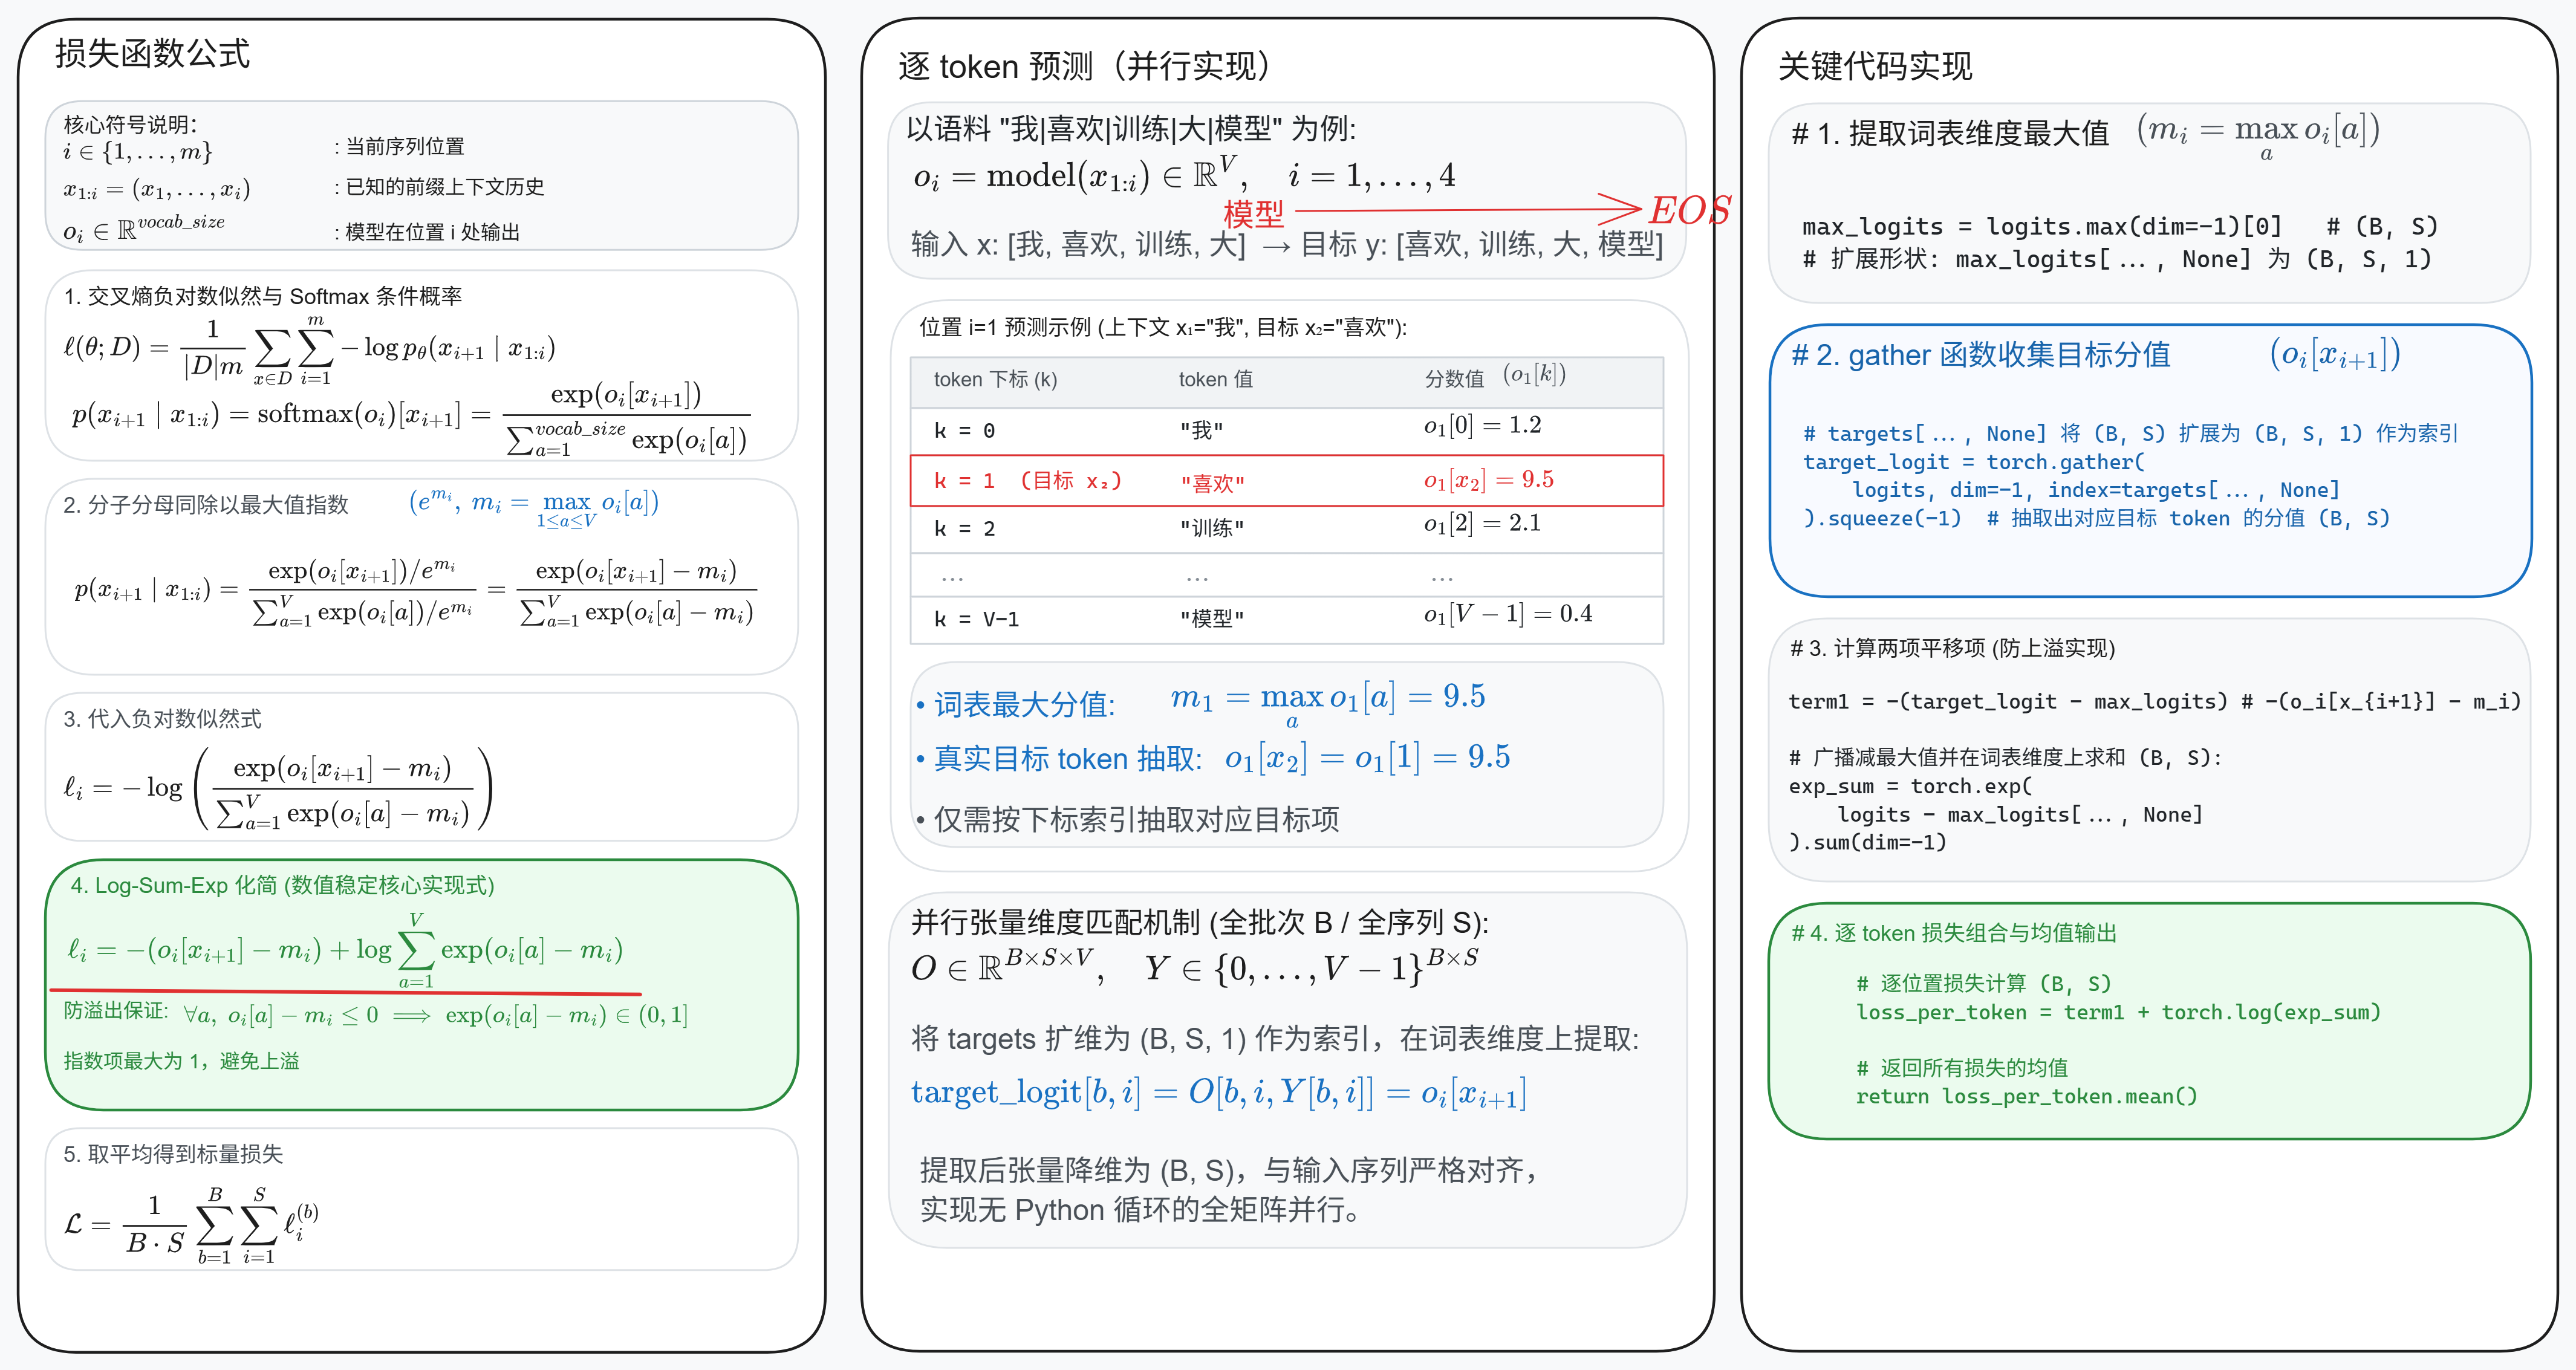

- 减去 logits 每一行的最大值再取 exp，避免 exp 上溢
- 尽量把 log 与 exp 运算抵消，即 $\exp(\log z) = z,\quad \log(\exp z)=z$
- 支持任意数量的 batch 维度，约定 batch 类维度排在词表维度之前，如 (batch_size, seq_len, vocab_size)

In [12]:
def cross_entropy(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    '''
    logits: (..., seq_len, vocab_size), 通常为 (batch_size, seq_len, vocab_size)
    targets: (..., seq_len) (B, S)
    '''
    # 交叉熵损失的计算：-log softmax(o)[target] = -(o[target] - max(o)) + log Σ exp(o - max(o))
    # 先减最大值再取 exp 避免上溢，log 与 exp 相互抵消

    # 1.默认不保留归约后的维度；2. max 返回的是元组 (最大值, 最大值对应的下标)
    max_logits = torch.max(logits, dim=-1)[0] # (B, S, V) -> (B, S)

    # max_logits.unsqueeze(-1) -> (B, S, 1); 等价于 max_logits[..., None]
    # max_logits.unsqueeze(-1).squeeze(-1) -> (B, S); squeeze(-1)：删除最后维度，仅当该维度大小等于 1

    # 在最后一维收集目标标签对应的 logit 值: logits[..., targets]; logits[targets] 只能在第一维取元素，与需求不符
    target_logits = torch.gather(logits, dim=-1, index=targets[..., None]).squeeze(-1) # (B, S, V), (B, S, 1) -> (B, S)

    term1 = -(target_logits - max_logits)
    exp_sum = torch.exp(logits - max_logits[..., None]).sum(dim=-1)
    loss = term1 + torch.log(exp_sum)
    return loss


`torch.gather()`用于在模型输出$o_i$中取到$x_{i+1}$对应的logits值，即$o_i[x_{i+1}]$，`target_logits = torch.gather(logits, dim=-1, index=targets[..., None]).squeeze(-1)`抽取出对应目标token的分值 (B, S)，`index=targets[..., None]`将(B, S)扩展为(B, S, 1)作为索引

官方的实现是`torch.nn.functional.cross_entroy()`

In [13]:
# 测试 cross_entropy
batch_size, seq_len, vocab_size = 2, 5, 1000

logits = torch.randn(batch_size, seq_len, vocab_size)          # 模型输出的未归一化分数 (B, S, V)
targets = torch.randint(0, vocab_size, (batch_size, seq_len))  # 目标 token 下标 (B, S)

loss = cross_entropy(logits, targets)
print(f"loss 形状：{loss.shape}")

# 与 PyTorch 官方实现对照，验证数值是否一致
import torch.nn.functional as F
ref = F.cross_entropy(logits.reshape(-1, vocab_size), targets.reshape(-1), reduction="none").view(batch_size, seq_len)

# 与 F.cross_entropy 的误差
(loss - ref)

loss 形状：torch.Size([2, 5])


tensor([[ 0.0000e+00,  0.0000e+00, -9.5367e-07,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00, -4.7684e-07,  0.0000e+00]])

## Optimizer
先看一个最简单的SGD优化器
最简单的基于梯度的优化器是随机梯度下降 SGD：从随机初始化的参数 $\theta_0$ 出发，每一步沿梯度的反方向前进一小步，更新公式如下：
$$\theta_{t+1} \leftarrow \theta_t - \alpha_t \nabla L(\theta_t; B_t)$$
其中 $B_t$ 是从数据集 $D$ 中随机采样的一批数据，学习率 $\alpha_t$ 与批次大小 $|B_t|$ 都是超参数。
先来看看如何实现一个 SGD 的变体：初始学习率为 $\alpha$，训练过程中学习率会衰减： $$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{t+1}} \nabla L(\theta_t; B_t)$$

In [14]:
from collections.abc import Callable, Iterable
from typing import Optional
import math

class SGD(torch.optim.Optimizer):
    '''
    PyTorch 中的优化器统一继承 torch.optim.Optimizer，需要实现两个方法：
    __init__(self, params, ...): 使用基类的 init 方法保存待优化参数和默认超参；
    step(self): 执行一次参数更新
    '''
    def __init__(self, params, lr=1e-3):
        """
        自定义SGD优化器构造函数
        :param params: 待优化的参数集合，可以是模型全部参数，也可以是分组参数
        :param lr: 学习率，超参数
        """
        if lr < 0:
            raise ValueError(f"Invalid learning rate: {lr}")
        defaults = {'lr': lr} # 把超参数都存到defaults字典里
        super().__init__(params, defaults)
    def step(self, closure: Optional[Callable] = None):
        """
        执行单步参数更新，反向传播完成 grad 计算之后调用此函数
        :param closure: 可选的闭包函数，用于重新计算 loss 并返回 loss 值，部分优化器需要使用（我们不用）
        :return: 如果传入 closure，返回 loss，否则返回 None
        """
        loss = None if closure is None else closure()
        for group in self.param_groups: # 遍历不同的参数组: 不同组可以指定不同的超参数，比如第一层参数用小一点的 lr，最后一层用大一点的 lr
            lr = group["lr"] # group 也是一个字典，取其中的 lr
            for p in group["params"]: # 遍历该组内的每个待优化参数 p
                if p.grad is None: # 梯度还没有计算出来，grad 属性为 None，跳过更新
                    continue

                state = self.state[p]  # self.state 字典：保存每个参数对应的状态信息，如迭代步数、动量等；state[p] 获取参数 p 对应的状态字典
                t = state.get("t", 0)  # 读取迭代计数 t；如果key "t" 不存在，返回默认值 0
                grad = p.grad.data  # 获取损失 loss 关于参数 p 的梯度张量
                p.data -= lr / math.sqrt(t + 1) * grad  # 原地更新参数：学习率随迭代步数做平方根衰减
                state["t"] = t + 1  # 更新状态里的迭代计数，步数 +1
        return loss

### AdamW
现代大模型通常会使用更复杂的优化器，比如 Adam 系列优化器。本节将实现目前较为主流的一种 Adam 变体，AdamW 优化器，它也是 LLaMA、GPT-3 等模型的选择。

AdamW 是有状态的：它为每个参数额外维护一阶矩 $m$ 与二阶矩 $v$ 的滑动估计，用额外的显存换取训练的稳定性与收敛速度。

在 AdamW 的语境下，moment 也常翻译成动量，如一阶动量

AdamW 涉及的超参数包括学习率 $\alpha$、矩估计的衰减率 $(\beta_1, \beta_2)$、权重衰减系数 $\lambda$ 与数值稳定项 $\varepsilon$。$(\beta_1, \beta_2)$ 常用值为 $(0.9, 0.999)$，LLaMA、GPT-3 用的是 $(0.9, 0.95)$。

AdawW 优化器的算法过程如下伪代码所示。
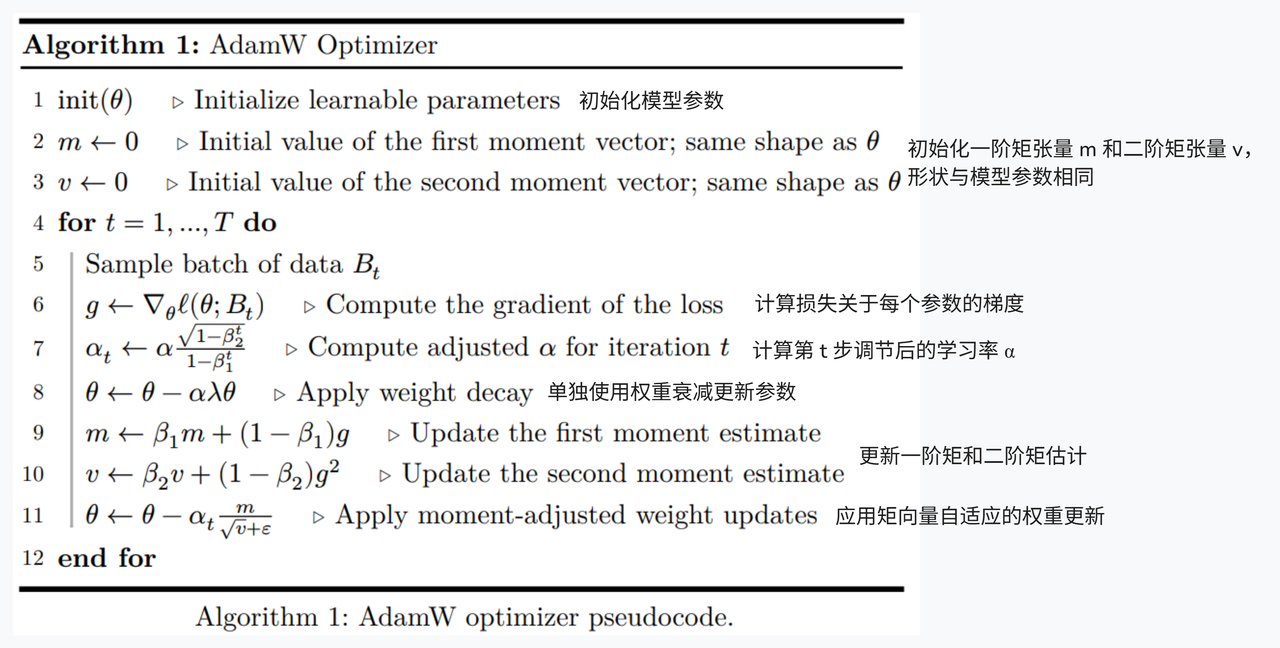
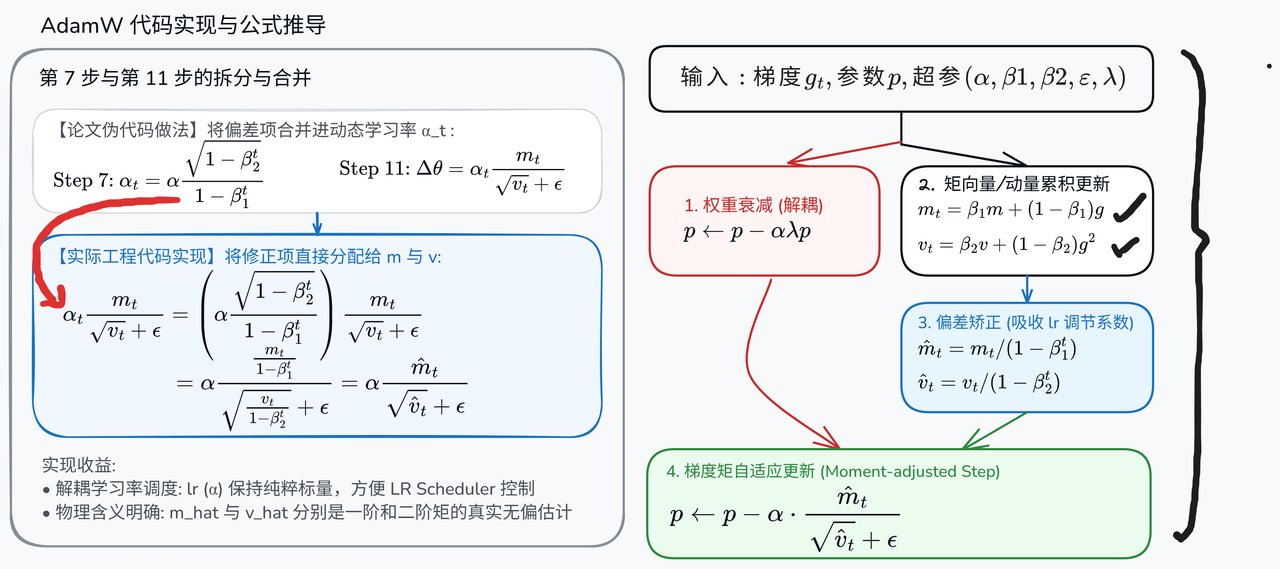


In [15]:
class AdamW(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay:float=0):
        '''
        lr: float  α, learning‑rate 学习率
        betas: tuple[float, float] (β1, β2), 一阶矩、二阶矩估计的指数衰减系数
        eps: float ε, 保证数值稳定性的小常数
        weight_decay: float λ, weight‑decay 权重衰减系数
        '''
        if lr < 0:
            raise ValueError(f"Invalid learning rate: {lr}")

        defaults = {'lr': lr, 'betas': betas, 'eps': eps, 'weight_decay': weight_decay} # 先把超参数存进defaults
        super().__init__(params, defaults) # 然后调用父类 Optimizer 的构造函数
    def step(self, closure: Optional[Callable]=None):
        """
        执行单步 AdamW 参数更新，反向传播计算完梯度后调用
        :param closure: 可选闭包函数，用于重计算 loss
        :return: loss，若传入 closure 返回 loss，否则返回 None
        """
        loss = None if closure is None else closure()

        # 遍历每一组参数 group
        for group in self.param_groups:
            # 获取本组参数使用的各种超参
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            eps = group["eps"]
            weight_decay = group["weight_decay"]
            for p in group["params"]: # 遍历该组内的每个待优化参数 p
                if p.grad is None: continue # 梯度还没有计算出来，grad 属性为 None，跳过更新

                state = self.state[p] # self.state 字典：保存每个参数对应的状态信息，如迭代步数、动量等；state[p] 获取参数 p 对应的状态字典
                t = state.get("t", 0) # 从状态字典读取迭代步数，初值为 0
                m = state.get("m", 0) # 一阶矩向量（first moment vector）
                v = state.get("v", 0) # 二阶矩向量（second moment vector）
                grad = p.grad.data # 获取损失关于参数 p 的梯度张量

                t += 1 # AdawW 里面 t 的取值范围为 1~T，代码里它的初值是 0，所以需要先加 1，再执行更新

                # 执行 AdamW 单步更新
                p.data -= lr * weight_decay * p.data # AdamW 的权重衰减：单独对权重做衰减


                m_t = beta1 * m + (1 - beta1) * grad # 更新一阶矩估计
                v_t = beta2 * v + (1 - beta2) * torch.pow(grad, 2) # 更新二阶矩估计

                state["t"] = t # 更新状态字典中的迭代步数
                state["m"] = m_t # 保存最新一阶矩到状态
                state["v"] = v_t # 保存最新二阶矩到状态

                m_hat = m_t / (1 - beta1 ** t) # 用 α 修正因子的分母调节一阶矩估计
                v_hat = v_t / (1 - beta2 ** t) # 用 α 修正因子的分子调节二阶矩估计
                p.data -= lr * m_hat / (torch.sqrt(v_hat) + eps) # 执行 moment-adjusted 的权重更新

        return loss


#### Why Weight Decay?

```python
p.data -= lr * weight_decay * p.data
```
就是 **Weight Decay 本身**。

假设参数为 $\theta$，学习率为 $\eta$，weight decay 系数为 $\lambda$，那么这一步就是：

$$
\theta \leftarrow \theta - \eta \lambda \theta
$$

也就是：

$$
\theta \leftarrow (1-\eta\lambda)\theta
$$
所以它做的事情非常直接：
> 每训练一步，都把参数缩小一点。

因此，**Weight Decay 本质上就是直接让参数逐渐向 $0$ 收缩。**

---
#### 为什么要直接缩小参数？

因为我们的目标并不只是：

$$
\min_\theta L(\theta)
$$

也希望模型不要依赖特别大的参数。

直觉上，如果两组参数都能把训练集拟合得很好：
那么通常希望优先选择更小的参数。

因此 Weight Decay 给模型施加了一个额外的约束：

> 如果一个参数没有足够强的梯度不断“维持”它，那么它就应该逐渐变小。

所以训练时实际上有两股力量：

$$
\text{Gradient Update}: \quad \text{根据数据决定参数应该往哪里移动}
$$

以及：

$$
\text{Weight Decay}: \quad \text{不断把参数往 }0\text{ 拉}
$$

最终参数是两者共同作用的结果。

---

#### Weight Decay本质上是一种正则化手段

在SGD中Weight Decay和L2 Regularization在数学上是**等价的**

$$
L'(\theta)=L(\theta)+\frac{\lambda}{2}\|\theta\|_2^2
$$

对参数求梯度：

$$
\nabla_\theta L'=\nabla_\theta L+\lambda\theta
$$

如果使用最普通的 SGD：
$$
\theta\leftarrow\theta-\eta\left(\nabla_\theta L+\lambda\theta\right)
$$

展开：

$$
\theta\leftarrow\theta-\eta\nabla_\theta L-\eta\lambda\theta
$$

重新整理：

$$
\theta\leftarrow(1-\eta\lambda)\theta-\eta\nabla_\theta L
$$

其中：

$$
-\eta\lambda\theta
$$

恰好就是 Weight Decay。

所以对于普通 SGD：

$$
\boxed{
\text{L2 Regularization}
\equiv
\text{Weight Decay}
}
$$

也就是说，**L2 Regularization 是从 loss 的角度描述，而 Weight Decay 是从参数更新的角度描述，同样可以实现“让参数变小”这个效果。**

---

#### 为什么 AdamW 要直接操作参数？

问题出现在 Adam 这种自适应优化器上。

如果使用 L2 Regularization，那么我们会先把$\lambda\theta$加入梯度：$g_t=\nabla L(\theta_t)+\lambda\theta_t$（平方项求导之后把2并入$\lambda$就是$g_t=\nabla L(\theta_t)+\lambda\theta_t$）

然后 Adam 会对整个 $g_t$ 计算一阶矩和二阶矩：

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

$\lambda\theta$一旦被并入总梯度 $g_t$，Adam 后面对 $g_t$ 的所有处理都会同时作用到它。

于是它不再是简单、直接的：$\theta\leftarrow(1-\eta\lambda)\theta$

AdamW 的想法就是把两件事拆开。

Adam 只负责梯度：

$$
\theta\leftarrow\theta-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
$$

Weight Decay 单独负责缩小参数：

$$
\theta\leftarrow(1-\eta\lambda)\theta
$$

代码对应：

```python
p.data -= lr * weight_decay * p.data
```

因此 AdamW 中的核心思想就是：**不要把 Weight Decay 混进 Adam 的梯度处理过程，而是直接对参数进行衰减。**

In [16]:
# 测试 AdamW：用同一个 toy 损失观察优化过程
weights = torch.nn.Parameter(5 * torch.randn((10, 10)))
opt = AdamW([weights], lr=1e2, weight_decay=0.01)

for t in range(20):
    opt.zero_grad()
    loss = (weights**2).mean()
    loss.backward()
    opt.step()
    if t % 5 == 0 or t == 19:
        print(f"step {t:2d}: loss = {loss.item():.4f}")


step  0: loss = 25.3841
step  5: loss = 1.1965
step 10: loss = 0.0007
step 15: loss = 0.0000
step 19: loss = 0.0000


## 学习率调度
让损失下降最快的学习率在训练过程中通常是变化的。Transformer 的惯例是先大后小，前期用较大学习率快速推进，后期逐步衰减以稳定收敛。
实现 LLaMA 采用的余弦退火调度（cosine annealing schedule），它的定义如下：
（预热）若 $t < T_w$：$\alpha_t = \dfrac{t}{T_w}\,\alpha_{max}$
（余弦退火）若 $T_w \le t \le T_c$：$\alpha_t = \alpha_{min} + \dfrac{1}{2}\left(1 + \cos\left(\dfrac{t - T_w}{T_c - T_w}\pi\right)\right)(\alpha_{max} - \alpha_{min})$
（退火结束）若 $t > T_c$：$\alpha_t = \alpha_{min}$
其中 $\alpha_{max}$、$\alpha_{min}$ 是最大与最小（最终）学习率，$T_w$ 是预热迭代步数，$T_c$ 是余弦退火的结束步数（若$T_c=900$，则余弦退火将在第 900 步结束）。下图给出了 $T_w=100 $、$T_c=900$ 对应的学习率变化曲线。

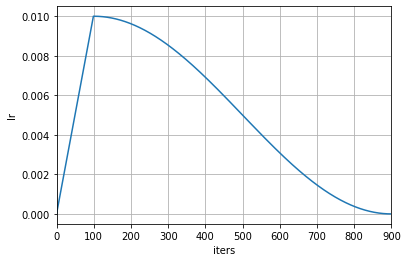

为什么要 warmup？训练初期参数是随机初始化的，梯度方向很不稳定，一上来就用大学习率容易让模型直接发散。先从小学习率线性预热到 $\alpha_{max}$，可以让模型先“稳住”再加速。
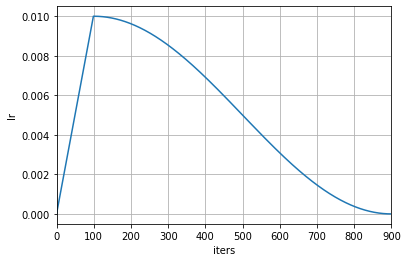

In [17]:
def learning_rate_schedule(
    it: int,
    max_learning_rate: float,
    min_learning_rate: float,
    warmup_iters: int,
    cosine_cycle_iters: int,
):
    '''
    it: int  当前迭代步数 t (t 从 0 开始); 实际训练时 t 应该是从 1 开始的
    max_learning_rate: float  α_max，最大学习率
    min_learning_rate: float  α_min，最小（最终）学习率
    warmup_iters: int  T_w，预热迭代数
    cosine_cycle_iters: int  T_c，余弦退火的结束步数
    return: float，第 it 步使用的学习率 α_t
    '''
    # 预热阶段：学习率从 0 线性升到 max_learning_rate
    if it < warmup_iters:
        return it / warmup_iters * max_learning_rate
    # 余弦退火阶段：按余弦曲线从 max_learning_rate 衰减到 min_learning_rate
    elif warmup_iters <= it <= cosine_cycle_iters:
        return min_learning_rate + 0.5 * (1 + math.cos((it - warmup_iters) / (cosine_cycle_iters - warmup_iters) * math.pi)) * (max_learning_rate - min_learning_rate)
    else:
        return min_learning_rate

## 梯度裁剪

训练中有时会遇到产生超大梯度的样本，影响训练稳定性。因此需要引入梯度裁剪。
梯度裁剪的做法很直接：每次反向传播之后、优化器更新之前，给梯度的范数设一个上限 $M$。把所有参数的梯度拼成一个向量 $g$，规则如下：
$$\|g\|_2 = \sqrt{\sum_g g^2}, \qquad \text{若 } \|g\|_2 \ge M \text{，则 } g \leftarrow \frac{M}{\|g\|_2 + \varepsilon}\, g$$
若 $\|g\|_2 < M$ 则不做处理。其中 $\varepsilon$ 是数值稳定常数，取 PyTorch 默认值 $10^{-6}$。裁剪后的范数会略小于 $M$（分母多了数值稳定项）。

In [18]:
def gradient_clipping(parameters: Iterable[torch.nn.Parameter], max_l2_norm: float, eps: float = 1e-6) -> None:
    # 把所有参数的梯度当成一个大向量，计算整体的 ℓ2 范数
    # 1. p.grad.pow(2).sum().item(): 对单个参数 梯度张量内的所有元素求平方和，得到该参数张量 梯度的平方和
    # 2. sum(... for p in parameters): 对所有参数张量的梯度平方和求和，得到所有参数的梯度的平方和
    l2_norm = math.sqrt(sum(p.grad.pow(2).sum().item() for p in parameters if p.grad is not None))
    if l2_norm > max_l2_norm:
        for p in parameters:
            with torch.no_grad():
                if p.grad is not None:
                    p.grad *= max_l2_norm / (l2_norm + eps)

In [19]:
# 测试 gradient_clipping：构造一组偏大的梯度，裁剪后检查整体范数
weights = torch.nn.Parameter(torch.randn(10, 10))
bias = torch.nn.Parameter(torch.randn(10))
loss = (weights ** 2).sum() * 100 + (bias ** 2).sum() * 100
loss.backward()

params = [weights, bias]
before = math.sqrt(sum(p.grad.pow(2).sum().item() for p in params))
gradient_clipping(params, max_l2_norm=1.0)
after = math.sqrt(sum(p.grad.pow(2).sum().item() for p in params))

print(f"裁剪前梯度范数：{before:.4f}")
print(f"裁剪后梯度范数：{after:.10f}")

裁剪前梯度范数：2125.2381
裁剪后梯度范数：0.9999999925


## 训练循环
原始文本经过分词后，会变成一条 token 序列 $x = (x_1, \ldots, x_n)$。原始语料由许多独立的文档组成，通常会把它们拼接成一条序列，只在文档之间插入分隔符（如 `<|endoftext|>`），这些符号有自己的 token ID。


In [20]:
import numpy as np
def get_batch(x: np.ndarray,
              batch_size: int,
              context_length: int,
              device: str) -> tuple[torch.Tensor, torch.Tensor]:
    '''
    x: np.ndarray  一维整数数组，元素为 token ID
    batch_size: int  B，批大小
    context_length: int  L，每条句子的上下文长度
    device: str  设备字符串，如 'cpu' or 'cuda:0'
    returns (input_seq, target_seq), 形状为 (batch_size, context_length)
    '''
    # 随机采样 B 个起始下标：取值范围 [0, len(x) - L + 1)，保证从起始下标出发，连续取 L 个 token 不会越界
    indices = np.random.randint(0, len(x) - context_length + 1, size=batch_size) # 最大起始下标为 len(x) - L, 句子里最后一个元素的下标为 len(x) - L + L - 1 < len(x)

    # indices[:, None] 将 indices 的形状从 (B,) 变成 (B, L), 与 (B, L) 进行广播相加后形状变为 (B, L)
    # 1 -> 1 2 3 L; 2 -> 2 3 4 L+1; m -> m m+1 m+2 m+L-1
    # m m m ...m + 0 1 2 ... L-1 = m m+1 m+2 m+L-1
    input_seq = x[indices[:, None] + np.arange(0, context_length)]   # (len(x),), (B, L) -> (B, L): 以扩展后的下标数组为索引，在 x 的第一个维度上取元素

    indices += 1 # target_seq 的起始下标全部加 1
    target_seq = x[indices[:, None] + np.arange(0, context_length)]  # (B, L)

    # 转成 torch 张量并放到指定设备上
    input_seq_tensor = torch.tensor(input_seq, device=device)
    target_seq_tensor = torch.tensor(target_seq, device=device)

    return (input_seq_tensor, target_seq_tensor)

  - `np.random.randint(low, high, size)`：在区间 [low, high) 生成 size 个随机整数序列。
  - `np.arange(start, stop, step)`：以 step 为间隔，在区间 [start, stop) 内生成连续序列

In [21]:
import numpy as np

# 使用例子：用一段很短的 token 序列观察采样结果
x = np.arange(20)   # 造一条长度为 20 的 token 序列：0, 1, 2, ..., 19
print("token 序列 x =", x)

inputs, targets = get_batch(x, batch_size=3, context_length=5, device="cpu")

print("\ninput  形状:", tuple(inputs.shape))
print(inputs)
print("target 形状:", tuple(targets.shape))
print(targets)

# 关键检查：target 的每一行 = input 对应行整体右移一格（第 i 位预测第 i+1 个 token）
print("\ntarget 是否等于 input 右移一格:", bool((targets == inputs + 1).all()))

token 序列 x = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

input  形状: (3, 5)
tensor([[ 8,  9, 10, 11, 12],
        [ 1,  2,  3,  4,  5],
        [ 0,  1,  2,  3,  4]])
target 形状: (3, 5)
tensor([[ 9, 10, 11, 12, 13],
        [ 2,  3,  4,  5,  6],
        [ 1,  2,  3,  4,  5]])

target 是否等于 input 右移一格: True


## 检查点保存与加载
- 训练过程可能会被打断（比如电脑抽风死机），我们需要能从被打断的前一刻恢复训练进度；即使一切顺利，也希望拿到中间模型去分析训练动态、对比不同阶段模型的文本预测效果。因此，需要把训练状态保存到磁盘。一个合格的检查点必须包含恢复训练所需的全部状态，共三样：
- 模型权重（必须的）：PyTorch 中每个 `nn.Module` 都有 `state_dict()`，返回保存全部可学习权重的字典，之后用配套的 `load_state_dict()` 装回去。
- 优化器状态：如果用的是有状态优化器（如 AdamW），还要保存它的一阶矩、二阶矩估计。优化器同样有 `state_dict()` / `load_state_dict()`。
- 迭代步数：记录走到哪一步训练了，动态学习率也依赖于当前步数。
设计要点：
- 保存时使用`torch.save(obj, out)` ，out 既可以是路径也可以是文件对象
- 读取时用 `torch.load(src, map_location=device)`，可直接把张量放到模型当前所在的设备

In [22]:
import os
import typing
import torch

from torch.nn import Module
from torch.optim import Optimizer

def save_checkpoint(model: Module, optimizer: Optimizer, iteration: int, out: str | os.PathLike | typing.BinaryIO | typing.IO[bytes]) -> None:
    '''
    model: torch.nn.Module  模型
    optimizer: torch.optim.Optimizer  优化器
    iteration: int  当前的迭代步数
    out: str | os.PathLike | typing.BinaryIO | typing.IO[bytes]  保存路径或文件对象
    '''
    # state_dict() 返回保存全部可学习权重的字典；优化器同理（AdamW 的 m / v 等状态也在里面）
    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(), "iter_num": iteration}, out)

def load_checkpoint(src: str | os.PathLike | typing.BinaryIO | typing.IO[bytes], model: Module, optimizer:Optimizer) -> int:
    '''
    src: str | os.PathLike | typing.BinaryIO | typing.IO[bytes]  检查点路径或文件对象
    model: torch.nn.Module
    optimizer: torch.optim.Optimizer
    returns: int，检查点中保存的迭代步数
    '''
    device = next(model.parameters()).device
    state_dict = torch.load(src, map_location=device) # 加载到模型当前所在的设备上
    model.load_state_dict(state_dict["model"])
    if optimizer is not None:
        optimizer.load_state_dict(state_dict["optimizer"])
    return state_dict["iter_num"]

`model.parameters()` 会返回模型所有参数的一个迭代器，所以要用`next()`来取模型的第一个参数

## 完整训练循环
先写单步，再写循环

In [23]:
def train_step(model: nn.Module, optimizer: torch.optim.Optimizer, x: torch.Tensor, y: torch.Tensor, lr, max_l2_norm: float = 1.0) -> float:
    '''
    model: torch.nn.Module  语言模型
    optimizer: torch.optim.Optimizer  优化器
    x: (batch_size, context_length)  输入 token ID，需为 long 类型
    y: (batch_size, context_length)  目标 token ID，即 x 整体右移一格
    lr: float  本步使用的学习率（由余弦调度给出）
    max_l2_norm: float  M，梯度裁剪允许的最大 ℓ2 范数
    return: float  本步的损失值（标量）
    '''
    optimizer.param_groups[0]["lr"] = lr

    logits = model(x)
    loss = cross_entropy(logits, y).mean()

    optimizer.zero_grad()
    loss.backward()
    gradient_clipping(model.parameters(), max_l2_norm)
    optimizer.step()

    return loss.item()


为什么`optimizer.param_groups[0]`？
```python
optimizer.param_groups = [
    {
        "params": [...模型参数...],
        "lr": 1e-3,
        "weight_decay": 0.01,
        "betas": (0.9, 0.999),
        "eps": 1e-8,
        ...
    }
]
```
取第一个group

为什么要有 param_groups，而不是优化器只有一个 lr？

因为真实训练中，不同参数可能需要不同的优化超参数。例如：
```python
optimizer = torch.optim.AdamW([
    {
        "params": model.backbone.parameters(),
        "lr": 1e-4,
    },
    {
        "params": model.head.parameters(),
        "lr": 1e-3,
    }
])
```

In [24]:
# 使用例子：用超小的 TransformerLM 跑一步，确认单步训练函数能跑通
# （完整训练循环：学习率调度 + 验证 + 检查点 + 日志，见同目录下的 train_llm.py）
torch.manual_seed(0)
vocab_size, context_length = 256, 32
model = TransformerLM(vocab_size=vocab_size,
                      context_length=context_length,
                      d_model=64,
                      num_layers=2,
                      num_heads=4,
                      d_ff=128,
                      rope_theta=10000.0)

# 优化器用 2.2.2 实现的 AdamW（接口与 torch.optim.AdamW 一致）
optimizer = AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.95), weight_decay=0.01)

# 造一份有规律的 toy 数据：0,1,2,...,255 循环出现
data = np.tile(np.arange(vocab_size, dtype=np.int32), 80)

print(f"数据集(部分): {data[:10]}")
print("随机初始化时约为 ln(256) ≈ 5.55")

for i in range(50):
    x, y = get_batch(data, batch_size=4, context_length=context_length, device="cpu")
    loss = train_step(model, optimizer, x.long(), y.long(), lr=1e-3)
    if i % 5 == 0:
        print(f"第 {i} 步训练后的损失：{loss:.4f}")

数据集(部分): [0 1 2 3 4 5 6 7 8 9]
随机初始化时约为 ln(256) ≈ 5.55
第 0 步训练后的损失：5.9196
第 5 步训练后的损失：4.9654
第 10 步训练后的损失：5.3304
第 15 步训练后的损失：3.5354
第 20 步训练后的损失：3.2782
第 25 步训练后的损失：3.0913
第 30 步训练后的损失：2.0905
第 35 步训练后的损失：1.9540
第 40 步训练后的损失：1.5258
第 45 步训练后的损失：2.0754


In [25]:
import os
import time
import argparse
import numpy as np
import torch
import wandb
def train_llm(model: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              train_data: np.ndarray,
              val_data: np.ndarray,
              args) -> None:
    '''
    训练循环：反复调用 train_step，并按间隔做验证、保存检查点与记录日志

    train_data / val_data: np.ndarray  token ID 数组（大数据集建议用 np.load(路径, mmap_mode="r") 打开）
    args: 超参集合，字段见 parse_args()
    '''
    start_time = time.time()

    for i in range(1, args.total_iters + 1):
        model.train()   # 切到训练模式（启用 dropout 等）

        # 1. 取一批训练数据，并算出本步的学习率
        x, y = get_batch(train_data, args.batch_size, args.context_length, args.device)
        lr = learning_rate_schedule(i, args.max_lr, args.min_lr,
                                    args.warmup_iters, args.cosine_cycle_iters)

        # 2. 单步训练：前向 → 损失 → 反向 → 裁剪 → 更新
        loss = train_step(model, optimizer, x.long(), y.long(), lr=lr, max_l2_norm=args.max_l2_norm)

        # 3. 记录训练指标
        #   wandb.log("iter": i, "train_loss": loss, "wall_time": time.time() - start_time)
        #   上面等价于下面的print，wandb只是额外把数值画成曲线存进网页端看板
        print(f"iter {i:5d} train_loss={loss:.4f}  val_loss={loss:.4f} wall_time={time.time() - start_time}s")

        # 4. 定期在验证集上评估：torch.no_grad() 下不建图，也不更新参数
        if i % args.val_interval == 0:
            model.eval()   # 切到评估模式（关闭 dropout 等）
            with torch.no_grad():
                val_x, val_y = get_batch(val_data, args.batch_size, args.context_length, args.device)
                val_loss = cross_entropy(model(val_x.long()), val_y.long()).mean().item()

            print(f"iter {i:5d}  train_loss={loss:.4f}  val_loss={val_loss:.4f}")

        # 5. 定期保存检查点（最后一步一定保存）
        if i % args.save_interval == 0 or i == args.total_iters:
            checkpoint_path = os.path.join(args.save_dir, f"iter{i:06d}.pt")
            save_checkpoint(model, optimizer, i, checkpoint_path)
            print(f"iter {i:5d}  已保存检查点 → {checkpoint_path}")

# ------------------------------------------------------------------ 超参与入口
def parse_args():
    parser = argparse.ArgumentParser(description="训练一个 Transformer 语言模型")

    # 数据
    parser.add_argument("--dataset_name", type=str, default="TinyStoriesV2-GPT4")
    # 数据路径：默认指向项目里的 TinyStories 分词结果（相对项目根目录），
    # 换数据集时用这两个参数覆盖即可。
    parser.add_argument("--train_data_path", type=str,
                        default="data/TinyStories/TinyStoriesV2-GPT4-train.npy")
    parser.add_argument("--val_data_path", type=str,
                        default="data/TinyStories/TinyStoriesV2-GPT4-valid.npy")

    # 优化器超参
    parser.add_argument("--max_lr", type=float, default=6e-4)
    parser.add_argument("--min_lr", type=float, default=6e-5)
    parser.add_argument("--weight_decay", type=float, default=0.01)
    parser.add_argument("--beta1", type=float, default=0.9)
    parser.add_argument("--beta2", type=float, default=0.95)

    # 训练超参
    parser.add_argument("--batch_size", type=int, default=32)
    parser.add_argument("--total_iters", type=int, default=5000)
    parser.add_argument("--warmup_iters", type=int, default=500)
    parser.add_argument("--cosine_cycle_iters", type=int, default=5000)
    parser.add_argument("--max_l2_norm", type=float, default=1.0)
    parser.add_argument("--val_interval", type=int, default=100)
    parser.add_argument("--save_interval", type=int, default=500)
    # 检查点根目录（相对项目根目录）；实际保存位置是 {save_dir}/{dataset_name}/{run_name}/，见 main() 里的拼接
    parser.add_argument("--save_dir", type=str, default="results/checkpoints")
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--run_name", type=str, default=None,
                        help="实验名，同时用作 W&B run 名与检查点目录名；实验脚本统一传 "
                             "「类型-lr峰值_谷值-bs-种子」（如 lr_sweep-lr3e-4_3e-5-bs64-s2026），"
                             "不传时按 数据集-bs-学习率[-消融名]-种子 自动生成")
    parser.add_argument("--wandb_mode", type=str, default=os.getenv("WANDB_MODE", "online"),
                        help="wandb 运行模式：online 实时上传到云端（需能联网且已 wandb login）；"
                             "offline 只写本地 ./wandb，之后可 wandb sync 补传。"
                             "也认环境变量 WANDB_MODE，方便在实验脚本里统一开关")
    parser.add_argument("--device", type=str, default="auto",
                        help="计算设备：auto 自动挑 cuda/cpu，也可显式写 cuda、cuda:0、cpu")
    parser.add_argument("--amp", action="store_true",
                        help="开启 bf16 混合精度；设备不是 CUDA 时自动忽略")

    # 模型超参，默认使用基准值（CS336 Assignment 1, §7.2）
    parser.add_argument("--vocab_size", type=int, default=10000)
    parser.add_argument("--context_length", type=int, default=256)
    parser.add_argument("--d_model", type=int, default=512)
    parser.add_argument("--num_layers", type=int, default=4)
    parser.add_argument("--num_heads", type=int, default=16)
    parser.add_argument("--rope_theta", type=float, default=10000.0,
                        help="RoPE 基数频率；传 0 即关闭位置编码（NoPE 消融）")
    # 默认 0.02 而不是 1.0：嵌入层参与残差主路径，标准差太大会让 logits 一开始就爆（尤其开了
    # --tie_embedding 时，输出头直接复用嵌入矩阵，std=1.0 下初始 loss 会到几百）
    parser.add_argument("--embed_init_std", type=float, default=0.02,
                        help="嵌入层初始化标准差；调小可抑制训练初期 loss 尖刺")

    # ---- 消融实验开关：默认全关，即标准 Pre-Norm + RMSNorm + SwiGLU 结构 ----
    parser.add_argument("--no_rmsnorm", action="store_true", help="消融：去掉全部 RMSNorm") # python train_llm.py
    parser.add_argument("--post_norm", action="store_true", help="消融：Pre-Norm 改成 Post-Norm")
    parser.add_argument("--no_gated_ffn", action="store_true", help="消融：SwiGLU 改成普通 SiLU 前馈网络")
    parser.add_argument("--tie_embedding", action="store_true", help="性能优化：输出头与输入嵌入共享权重")
    parser.add_argument("--ablation_name", type=str, default=None,
                        help="本次消融的简短代号（如 post_norm），会写进 run_name 方便网页端分组查看")

    return parser.parse_args()


def main():
    args = parse_args()

    # ---- 数据：mmap_mode="r" 以内存映射方式打开，不会一次性把整个数据集读进内存 ----
    # 默认指向项目里的 TinyStories
    train_data = np.load(args.train_data_path, mmap_mode="r")
    val_data = np.load(args.val_data_path, mmap_mode="r")
    print(f"run {args.run_name}｜训练集 {train_data.shape}，验证集 {val_data.shape}，设备 {args.device}")

    d_ff = 64 * (args.d_model * 8 // 3 // 64)         # SwiGLU：8/3 * d_model

    model = TransformerLM(
        vocab_size=args.vocab_size,
        context_length=args.context_length,
        d_model=args.d_model,
        num_layers=args.num_layers,
        num_heads=args.num_heads,
        d_ff=d_ff,
        rope_theta=args.rope_theta,
    ).to(args.device)

    optimizer = AdamW(model.parameters(),
                      lr=args.max_lr,
                      betas=(args.beta1, args.beta2),
                      weight_decay=args.weight_decay)

    train_llm(model, optimizer, train_data, val_data, args)

if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] [--dataset_name DATASET_NAME]
                             [--train_data_path TRAIN_DATA_PATH]
                             [--val_data_path VAL_DATA_PATH] [--max_lr MAX_LR]
                             [--min_lr MIN_LR] [--weight_decay WEIGHT_DECAY]
                             [--beta1 BETA1] [--beta2 BETA2]
                             [--batch_size BATCH_SIZE]
                             [--total_iters TOTAL_ITERS]
                             [--warmup_iters WARMUP_ITERS]
                             [--cosine_cycle_iters COSINE_CYCLE_ITERS]
                             [--max_l2_norm MAX_L2_NORM]
                             [--val_interval VAL_INTERVAL]
                             [--save_interval SAVE_INTERVAL]
                             [--save_dir SAVE_DIR] [--seed SEED]
                             [--run_name RUN_NAME] [--wandb_mode WANDB_MODE]
                             [--device DEVICE] [--amp]
                             [--vocab_

SystemExit: 2

E:\Anaconda\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# 训练资源估算：参数、显存、FLOPs 与训练时间

对应 **Problem 19：Transformer 模型资源估算**，四问依次为：

| | 问题 |
|---|---|
| (a) | 两套配置的参数量与 FP32 模型显存 |
| (b) | `batch_size = 16 / 32 / 64` 时的训练显存估算 |
| (c) | `batch_size = 64` 时的单步训练 FLOPs |
| (d) | `MFU = 0.4`、训练 10,000 步、RTX 3090 Ti 下的训练时间估算 |

下面一个小问对应一个代码块。

In [ ]:
# 两套配置：左为 GPT-2 XL 规模，右为 3.2 节实际训练使用的实验配置
GPT2_XL_SCALE = dict(vocab_size=50257, context_length=1024, num_layers=48,
                     d_model=1600, num_heads=25, d_ff=4288)
OURS = dict(vocab_size=10000, context_length=256, num_layers=4, d_model=512, num_heads=16, d_ff=1344)

# 公共估算参数
FP32_BYTES = 4
GIB = 1024 ** 3 # 10^9
GPU_PEAK_FLOPS = 8.0e13   # RTX 3090 Ti：BF16 输入、FP32 累加的 Tensor Core 稠密矩阵峰值算力
MFU = 0.4                 # Model FLOPs Utilization = 实际算力/峰值算力

In [ ]:
# ==================== (a) 参数量与 FP32 模型显存 ====================

def count_params(vocab_size, d_model, num_layers, num_heads, d_ff):
    """假设 RMSNorm 仅含缩放参数、Linear 无 bias、Embedding 与 LM Head 不共享权重。"""
    assert d_model % num_heads == 0

    embedding = vocab_size * d_model
    per_layer = (
        d_model                    # Attention 前 RMSNorm
        + 4 * d_model * d_model    # Q / K / V / O
        + d_model                  # FFN 前 RMSNorm
        + 3 * d_model * d_ff       # SwiGLU：w1 / w2 / w3
    )
    final_norm = d_model
    lm_head = d_model * vocab_size

    return embedding + num_layers * per_layer + final_norm + lm_head


for name, cfg in [("GPT-2 XL 规模", GPT2_XL_SCALE), ("我们的实验配置", OURS)]:
    n_params = count_params(**{k: v for k, v in cfg.items() if k != "context_length"})
    print(f"{name}: 参数量 {n_params / 1e6:.2f} M ｜ FP32 模型显存 {n_params * FP32_BYTES / GIB:.3f} GiB")

In [ ]:
# ==================== (b) batch_size = 16 / 32 / 64 时的训练显存估算 ====================

# 训练显存 = 参数 + 梯度 + 优化器状态（AdamW 的 m、v 共两份）+ 激活值
# 为简化估算，本题统一按 FP32，即每个数占 4 Bytes。
# 激活值按朴素 Transformer 实现粗略估算；CUDA 工作区、缓存分配等额外开销暂不考虑。

def estimate_memory(vocab_size, context_length, d_model, num_layers, num_heads, d_ff, batch_size):
    """粗略估算训练时主要显存占用，返回参数、梯度、优化器状态和激活值四部分。"""
    assert d_model % num_heads == 0
    S, d, h, d_head = context_length, d_model, num_heads, d_model // num_heads

    # 输入 token 向量序列（Embedding 输出）：(S, d)，相较于各层主要激活较小，本题忽略。
    # 一个样本 / 一条序列在前向传播过程中需要保存、供反向传播使用的主要激活值
    # ---- 每个 Transformer Block ----
    rms_attn = S * d                              # Attention 前 RMSNorm 的输出

    attn = (
        S * 3 * d                                 # Q、K、V 三份
        + h * S * S * 2                           # Attention score + Softmax probability
        + h * S * d_head                          # 各头逐位置的注意力加权输出（拼接前）
        + S * d * 2                               # 多头拼接结果 + 输出投影结果
    )

    rms_ffn = S * d                               # FFN 前 RMSNorm 的输出

    ffn = (
        S * d_ff * 4                              # w1、w3 输出 + SiLU(w1) + 门控结果
        + S * d                                   # w2 输出
    )

    # ---- 模型输出部分 ----
    final_norm = S * d                            # 最后的 RMSNorm
    logits = S * vocab_size                       # LM Head 输出 logits
    loss = S                                      # 每个位置的 loss

    # 单个样本的激活值总量，再统一乘 batch_size
    activation_per_sample = (
        num_layers * (rms_attn + attn + rms_ffn + ffn)
        + final_norm + logits + loss
    )
    activation = batch_size * activation_per_sample

    # 参数、梯度和优化器状态只与模型规模有关，不随 batch_size 改变
    n_params = count_params(vocab_size, d_model, num_layers, num_heads, d_ff)

    return {
        "参数": n_params * FP32_BYTES,
        "梯度": n_params * FP32_BYTES,             # 梯度与参数一一对应，同样大小
        "优化器状态": 2 * n_params * FP32_BYTES,    # AdamW 的一阶矩 m 与二阶矩 v
        "激活值": activation * FP32_BYTES,
    }


for name, cfg in [("GPT-2 XL 规模", GPT2_XL_SCALE), ("我们的实验配置", OURS)]:
    print(f"\n--- {name} ---")
    for batch_size in [16, 32, 64]:
        mem = estimate_memory(batch_size=batch_size, **cfg)
        parts = " ｜ ".join(f"{k} {v / GIB:.2f} GiB" for k, v in mem.items())
        print(f"batch_size={batch_size:2d} → 合计 {sum(mem.values()) / GIB:.2f} GiB ｜ {parts}")


# 会随 batch_size 变化的主要是激活值，并且在这一粗略模型下近似线性增长；
# 参数、梯度和优化器状态只由模型规模决定。

# 使用 “我们的实验配置” 在 3090 Ti 上跑 batch_size=64，显存使用量大概为 7600 MB，约合 7.4 GB。

# 实际训练峰值显存还会受到 Attention 实现、CUDA 上下文、算子工作区、
# CUDA 缓存分配器等因素影响，因此这里主要用于估计数量级。

In [ ]:
# ==================== (c) batch_size = 64 时的单步训练 FLOPs ====================

def estimate_forward_flops(vocab_size, context_length, d_model, num_layers, num_heads, d_ff):
    """估算单个样本 / 一条序列完成一次前向传播的主要 FLOPs。

    核心事实：
    矩阵乘法 (M,N) @ (N,P) -> (M,P)，约需要 2*M*N*P FLOPs。

    变量约定：
    S = context_length
    d = d_model
    h = num_heads
    d_head = d // h



    RMSNorm、Softmax、SiLU 等逐元素操作相比矩阵乘法计算量较小，本题做粗略估算时忽略。
    比如 RMSNorm 会对序列中的每个 token 向量独立求均方根、做可学习参数缩放等，数量级为 O(S * d)，
    远小于 mha 内部的矩阵乘 O(S * d * d)
    """
    assert d_model % num_heads == 0
    S, d, h, d_head = context_length, d_model, num_heads, d_model // num_heads

    # ---- Multi-Head Attention ----
    mha = (
        2 * S * d * (3 * d)                      # QKV 投影：(S,d) @ (d,3d) -> (S,3d)
        + h * 2 * S * d_head * S                 # Q @ K^T：每个头 (S,d_head) @ (d_head,S) -> (S,S)
        + h * 2 * S * S * d_head                 # Attn @ V：每个头 (S,S) @ (S,d_head) -> (S,d_head)
        + 2 * S * d * d                          # 输出投影：(S,d) @ (d,d) -> (S,d)
    )

    # ---- SwiGLU FFN ----
    ffn = (
        2 * S * d * d_ff                         # w1 变换：(S,d) @ (d,d_ff) -> (S,d_ff)
        + 2 * S * d * d_ff                       # w3 变换：(S,d) @ (d,d_ff) -> (S,d_ff)
        + 2 * S * d_ff * d                       # w2 变换：(S,d_ff) @ (d_ff,d) -> (S,d)
    )

    # ---- 所有 Transformer Block ----
    blocks = num_layers * (mha + ffn)

    # ---- LM Head ----
    lm_head = 2 * S * d * vocab_size             # (S,d) @ (d,V) -> (S,V)

    return {
        "MHA": num_layers * mha,
        "FFN": num_layers * ffn,
        "LM Head": lm_head,
        "合计": blocks + lm_head,
    }


BATCH_SIZE = 64

# 反向传播计算量约为前向的 2 倍：
# 因此：
#   单步训练 FLOPs ≈ 前向 + 反向 ≈ 3 × 前向
# AdamW 参数更新主要是逐元素操作，相比矩阵乘法计算量较小，可忽略。

for name, cfg in [("GPT-2 XL 规模", GPT2_XL_SCALE), ("我们的实验配置", OURS)]:
    # estimate_forward_flops() 返回的是单个样本的前向 FLOPs，
    # 这里统一乘 batch_size 得到整个 batch 的计算量。
    forward = estimate_forward_flops(**cfg)["合计"] * BATCH_SIZE
    backward = 2 * forward
    train_step = forward + backward

    print(
        f"{name}: 前向 {forward / 1e12:.2f} TFLOPs ｜ "
        f"反向 {backward / 1e12:.2f} TFLOPs ｜ "
        f"单步训练 {train_step / 1e12:.2f} TFLOPs"
    )

    # K M G T 10^12

In [ ]:
# ==================== (d) MFU = 0.4、10,000 步、RTX 3090 Ti 下的训练时间估算 ====================

# RTX 3090 Ti：
# 假设矩阵乘法采用 BF16 输入、FP32 累加，
# Tensor Core 稠密矩阵理论峰值算力约为 80 TFLOP/s。
#
# MFU = 实际有效算力 / 理论峰值算力
# 因此：实际有效算力 = GPU 峰值算力 × MFU

GPU_PEAK_FLOPS = 8.0e13
MFU = 0.4
BATCH_SIZE = 64
NUM_STEPS = 10_000


def estimate_train_time(train_flops_per_step, gpu_peak_flops, mfu, num_steps):
    """根据单步训练 FLOPs、GPU 峰值算力和 MFU 粗略估算训练时间。"""
    effective_flops = gpu_peak_flops * mfu
    seconds_per_step = train_flops_per_step / effective_flops
    total_seconds = seconds_per_step * num_steps
    return seconds_per_step, total_seconds


for name, cfg in [("GPT-2 XL 规模", GPT2_XL_SCALE), ("我们的实验配置", OURS)]:
    # 先计算单个样本的前向 FLOPs，再统一乘 batch_size
    forward = estimate_forward_flops(**cfg)["合计"] * BATCH_SIZE

    # 反向传播约为前向的 2 倍，因此单步训练约为 3 × 前向
    train_flops_per_step = 3 * forward

    sec_per_step, total_sec = estimate_train_time(
        train_flops_per_step, GPU_PEAK_FLOPS, MFU, NUM_STEPS
    )

    print(
        f"{name}: "
        f"单步训练 {train_flops_per_step / 1e12:.2f} TFLOPs ｜ "
        f"每步约 {sec_per_step:.4f} s ｜ "
        f"{NUM_STEPS:,} 步约 {total_sec / 3600:.2f} 小时"
    )


# MFU = 0.4 是题目给定的理论估算值。
# 实际训练中，尤其对于较小模型，GPU 很难长期达到这一利用率，
# 因此真实训练时间可能明显长于上述估算结果。
# 我使用 “我们的实验配置” 在 3090 Ti 上跑 5000 步，大约花了 1700s，约 0.47 小时。
# 10000 -> 0.92 小时
# 实际 MFU = 0.4 / 6 = 0.065

# 文本生成
模型训练完成后，接下来就该让它生成文本了（即解码）。模型每一步根据当前序列预测下一个 token，再将采样结果追加到末尾，作为下一步预测的输入。重复这一过程直到生成结束。
本节主要介绍这个循环过程和两个常见的解码技巧。

单步解码/生成一个 token。给定前缀 $x_{1\ldots t}$，取模型在第 t 个位置上的输出$v = \mathrm{TransformerLM}(x_{1\ldots t})_t \in \mathbb{R}^{vocab\_size} $作为下一个 token （第 t+1 个位置）的 logit 分数。

根据这些 logit 分数得到概率分布并采样下一个 token，再将其追加到输入末尾，作为下一轮输入。重复该过程，直到生成 <|endoftext|> 或达到最大生成长度。
当前实现每生成一个 token 都会重新计算整个输入序列。实际大模型会缓存前面已经计算出来的每个 token 的 key 和 value 值（即 KV Cache），避免重复计算。

技巧一：温度缩放。温度参数 $\tau$ 用来调节概率分布的尖锐程度：
$$q_i=\frac{\exp(v_i/\tau)}{\sum_j \exp(v_j/\tau)}$$
其中：
- $\tau=1$：保持原始分布；
- $\tau<1$：分布更集中，原始概率大的 token，缩放后概率会更大，生成结果更保守；
- $\tau>1$：分布更平缓，原始概率大的 token，缩放后概率会变小，生成结果更随机。

技巧二：top-p（核）采样。温度缩放之后，还可以去掉概率很低的长尾 token。将 $q$ 按概率从高到低排序，选择最小的前 $k$ 个 token，使得
$$\sum_{j=1}^{k} q_{(j)} \ge p$$
只保留这 $k$ 个 token 的概率，其余置零并重新归一化，再进行采样。这样可以避免从大量低概率 token 中采到明显不合理的结果。

In [ ]:
def decode(model, prompt, eot_token_id=None, max_new_tokens=256, temperature=0.5, top_p=0.9, context_length=256) -> list[int]:
    '''
    从语言模型采样生成，返回新生成的 token ID（包含 prompt）

    model: torch.nn.Module  输入 (batch, seq_len)，输出 (batch, seq_len, vocab_size)
    prompt: list[int]  已编码的 token ID 列表
    eot_token_id: int  结束符 <|endoftext|> 的 ID；None 表示不提前停止
    max_new_tokens: int  最多新生成的 token 数
    temperature: float  温度参数 τ，越小分布越尖锐（趋近贪心），越大越平缓
    top_p: float  Top-p 核采样阈值，只保留累计概率达到 p 的那一小撮候选
    context_length: int  模型最大上下文长度，每一步只保留最后这么多个 token 作为输入
    '''
    ids = list(prompt) # 提示词长度为 prompt_length
    x = torch.tensor(ids).unsqueeze(0)  # 补上 batch 维：(seq_len,) -> (1, seq_len)
    model.eval()
    torch.set_grad_enabled(False) # 全局开关，关闭梯度计算，不再构建计算图

    # 每轮产出一个 token：前向 → 取最后一个位置上的分布 → 采样 → 拼回输入
    for i in range(1, max_new_tokens + 1):          # 预测第 prompt_length + i 个位置上的 token（i 从 1 开始）
        x_input = x[:, -context_length:]            # 从倒数第 context_length 个元素开始，一直取到结尾；若 len(x) < context_length，就从第一个元素开始；保证输入长度不超过模型的上下文窗口
        pred_y = model(x_input)[:, -1, :]           # (1, vocab_size) 只要当前最后一个位置上的预测

        # 温度缩放：τ→0 时最大的 logit 一枝独秀（趋近贪心），τ 越大分布越平、越敢选低概率词
        probs = torch.softmax(pred_y / temperature, dim=-1).squeeze(0)   # (1, vocab_size) -> (vocab_size,)

        # top-p：先按概率从大到小排序并求前缀和，累计到 p 的那一段就是要保留的"核"
        sorted_probs, sorted_indices = probs.sort(descending=True) # 同时返回 (排序后的序列， 排序后的序列元素的原始下标/ token id)
        cumsum = sorted_probs.cumsum(dim=-1) # (vocab_size,)
        cutoff_idx = torch.searchsorted(cumsum, top_p)   # 找到第一个使前缀和 >= p 的下标，假设是 j；
        sorted_mask = torch.arange(cumsum.shape[-1], device=probs.device) <= cutoff_idx # 构建掩码数组，0~j-1 号元素为 true，剩余元素为 false
        # 0 1 2 ... vocab_size

        # mask 是按"排序后的顺序"创建的，需要通过 sorted_indices 映射回原始下标，再作用到原始顺序的 probs 上
        # ~sorted_mask 将非 top-p 位置设置为 true，再使用 sorted_indices[~sorted_mask] 仅保留 top-p 屏蔽的那些元素对应的下标，方便后续将这些下标对应的 probs 值置 0
        probs[sorted_indices[~sorted_mask]] = 0

        probs = probs / probs.sum()                  # 丢掉尾部之后要重新归一化
        next_token_id = torch.multinomial(probs, num_samples=1).item() # 按给定概率 probs 采样 num_samples 个元素（默认不放回采样，即采样出的多个元素互不相同）

        ids.append(next_token_id) # 将新生成的 token 加入到输入序列中（列表形式）
        x = torch.cat([x, torch.tensor([[next_token_id]], device=x.device)], dim=1) # 将新生成的 token 加入到输入序列中（张量形式）
        if eot_token_id is not None and next_token_id == eot_token_id: # 生成了结束符，解码提前终止
            break

    return ids


In [ ]:
import torch

# ---------- 例子 1：温度 τ 怎么改变采样分布 ----------
logits = torch.tensor([2.0, 1.0, 0.5, 0.2, -1.0])   # 5 个候选 token 的 logits

for tau in [0.1, 0.5, 1.0, 2.0]:
    p = torch.softmax(logits / tau, dim=-1)
    print(f"τ={tau:<4} → 概率 {[round(v, 3) for v in p.tolist()]}")
# τ=0.1  → [1.0,   0.0,   0.0,   0.0,   0.0  ]   ← 几乎 one-hot，等价于贪心
# τ=1.0  → [0.554, 0.204, 0.124, 0.092, 0.028]   ← 原始 softmax
# τ=2.0  → [0.369, 0.224, 0.174, 0.150, 0.082]   ← 明显被拉平，尾部候选机会变大

In [ ]:
# ---------- 例子 2：top-p 保留多少个候选 ----------
probs = torch.softmax(logits, dim=-1)               # 以 τ=1 的分布为例
for top_p in [0.5, 0.9, 1.0]:
    sorted_probs, _ = probs.sort(descending=True)
    cumsum = sorted_probs.cumsum(dim=-1)
    cutoff = torch.searchsorted(cumsum, top_p).item()
    print(f"top_p={top_p} → 保留前 {cutoff + 1} 个候选，其累计概率 {cumsum[cutoff]:.3f}")